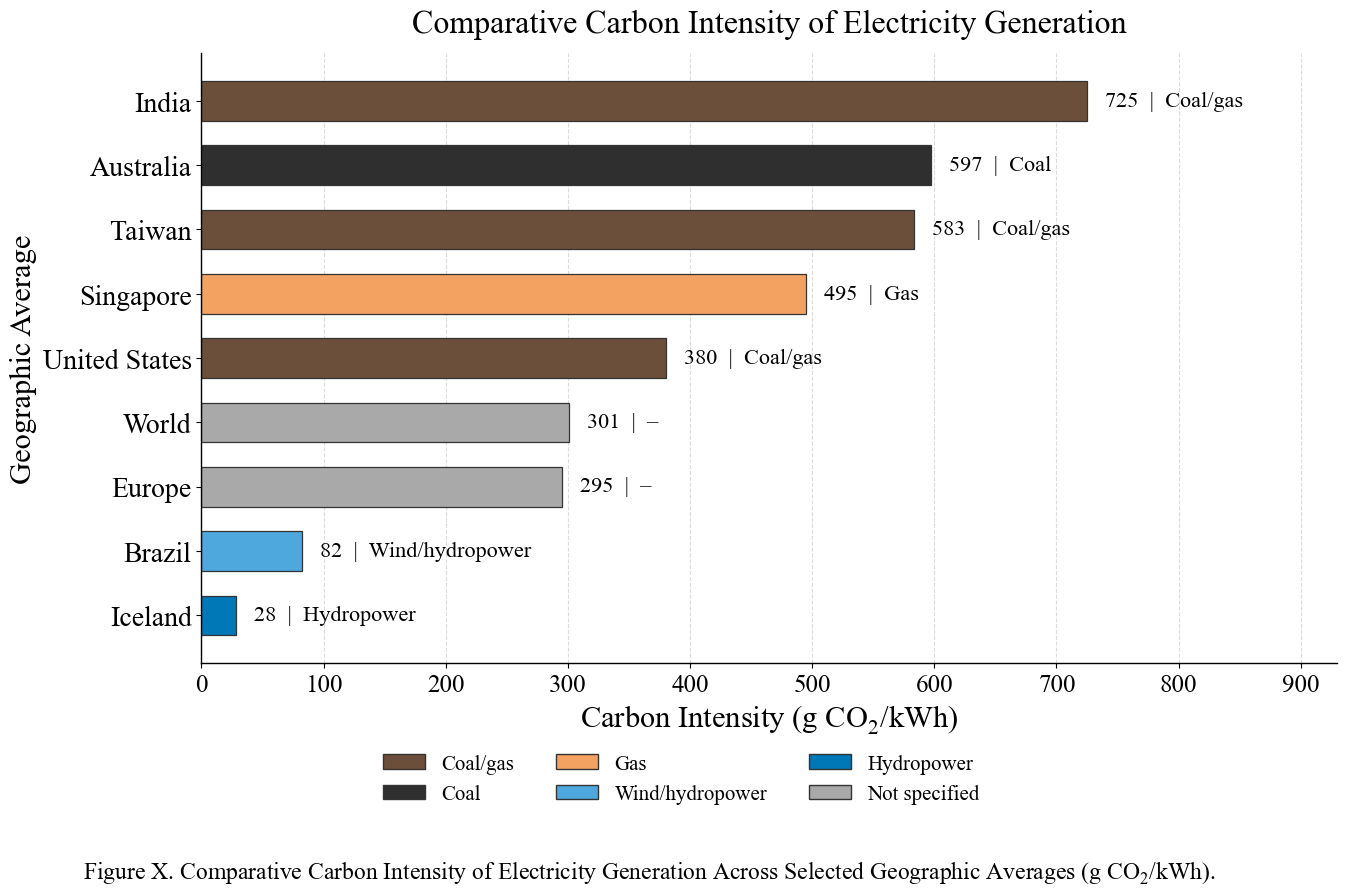

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Patch

# --------------------------------------------------
# Data: Geographic Carbon Intensity of Electricity
# --------------------------------------------------
locations = [
    "India",
    "Australia",
    "Taiwan",
    "Singapore",
    "United States",
    "World",
    "Europe",
    "Brazil",
    "Iceland"
]

carbon_intensity = np.array([
    725, 597, 583, 495, 380, 301, 295, 82, 28
])

dominant_energy_sources = [
    "Coal/gas",
    "Coal",
    "Coal/gas",
    "Gas",
    "Coal/gas",
    "–",
    "–",
    "Wind/hydropower",
    "Hydropower"
]

# --------------------------------------------------
# Color Code by Dominant Energy Source
# --------------------------------------------------
source_colors = {
    "Coal/gas": "#6B4F3A",          # Brown
    "Coal": "#2F2F2F",              # Dark gray
    "Gas": "#F4A261",               # Orange
    "Wind/hydropower": "#4EA8DE",   # Light blue
    "Hydropower": "#0077B6",        # Deep blue
    "–": "#A9A9A9"                  # Gray / not specified
}

bar_colors = [
    source_colors[source]
    for source in dominant_energy_sources
]

# --------------------------------------------------
# Times New Roman + Large Font Settings
# --------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 20,
    "axes.labelsize": 22,
    "axes.titlesize": 23,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 18,
    "ytick.labelsize": 20,
    "legend.fontsize": 15,

    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman:bold",
})

y = np.arange(len(locations))

# --------------------------------------------------
# Create Figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 10))

fig.subplots_adjust(
    left=0.22,
    right=0.93,
    top=0.84,
    bottom=0.23
)

# --------------------------------------------------
# Horizontal Bar Chart
# --------------------------------------------------
bars = ax.barh(
    y,
    carbon_intensity,
    height=0.62,
    color=bar_colors,
    edgecolor="0.20",
    linewidth=0.9
)

ax.set_yticks(y)
ax.set_yticklabels(locations, fontname="Times New Roman")
ax.invert_yaxis()

ax.set_xlim(0, 930)
ax.xaxis.set_major_locator(MultipleLocator(100))

ax.set_xlabel(
    r"Carbon Intensity (g CO$_2$/kWh)",
    fontname="Times New Roman"
)

ax.set_ylabel(
    "Geographic Average",
    fontname="Times New Roman"
)

ax.set_title(
    "Comparative Carbon Intensity of Electricity Generation",
    pad=15,
    fontweight="normal",
    fontname="Times New Roman"
)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.45
)

ax.set_axisbelow(True)

# --------------------------------------------------
# Carbon Intensity and Energy Source Labels
# --------------------------------------------------
for bar, value, source in zip(
    bars,
    carbon_intensity,
    dominant_energy_sources
):
    ax.text(
        value + 15,
        bar.get_y() + bar.get_height() / 2,
        f"{value}  |  {source}",
        va="center",
        ha="left",
        fontsize=16,
        fontname="Times New Roman"
    )

# --------------------------------------------------
# Remove Unnecessary Borders
# --------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --------------------------------------------------
# Legend
# --------------------------------------------------
legend_items = [
    Patch(facecolor="#6B4F3A", edgecolor="0.20", label="Coal/gas"),
    Patch(facecolor="#2F2F2F", edgecolor="0.20", label="Coal"),
    Patch(facecolor="#F4A261", edgecolor="0.20", label="Gas"),
    Patch(facecolor="#4EA8DE", edgecolor="0.20", label="Wind/hydropower"),
    Patch(facecolor="#0077B6", edgecolor="0.20", label="Hydropower"),
    Patch(facecolor="#A9A9A9", edgecolor="0.20", label="Not specified"),
]

fig.legend(
    handles=legend_items,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.52, 0.07),
    prop={"family": "Times New Roman", "size": 15}
)

# --------------------------------------------------
# Figure Caption
# --------------------------------------------------
fig.text(
    0.5,
    0.015,
    "Figure X. Comparative Carbon Intensity of Electricity Generation "
    "Across Selected Geographic Averages (g CO$_2$/kWh).",
    ha="center",
    fontsize=17,
    fontname="Times New Roman"
)

# --------------------------------------------------
# Save Files
# --------------------------------------------------
plt.savefig(
    "Figure_Geographic_Carbon_Intensity_Colored.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_Geographic_Carbon_Intensity_Colored.pdf",
    bbox_inches="tight"
)

plt.show()

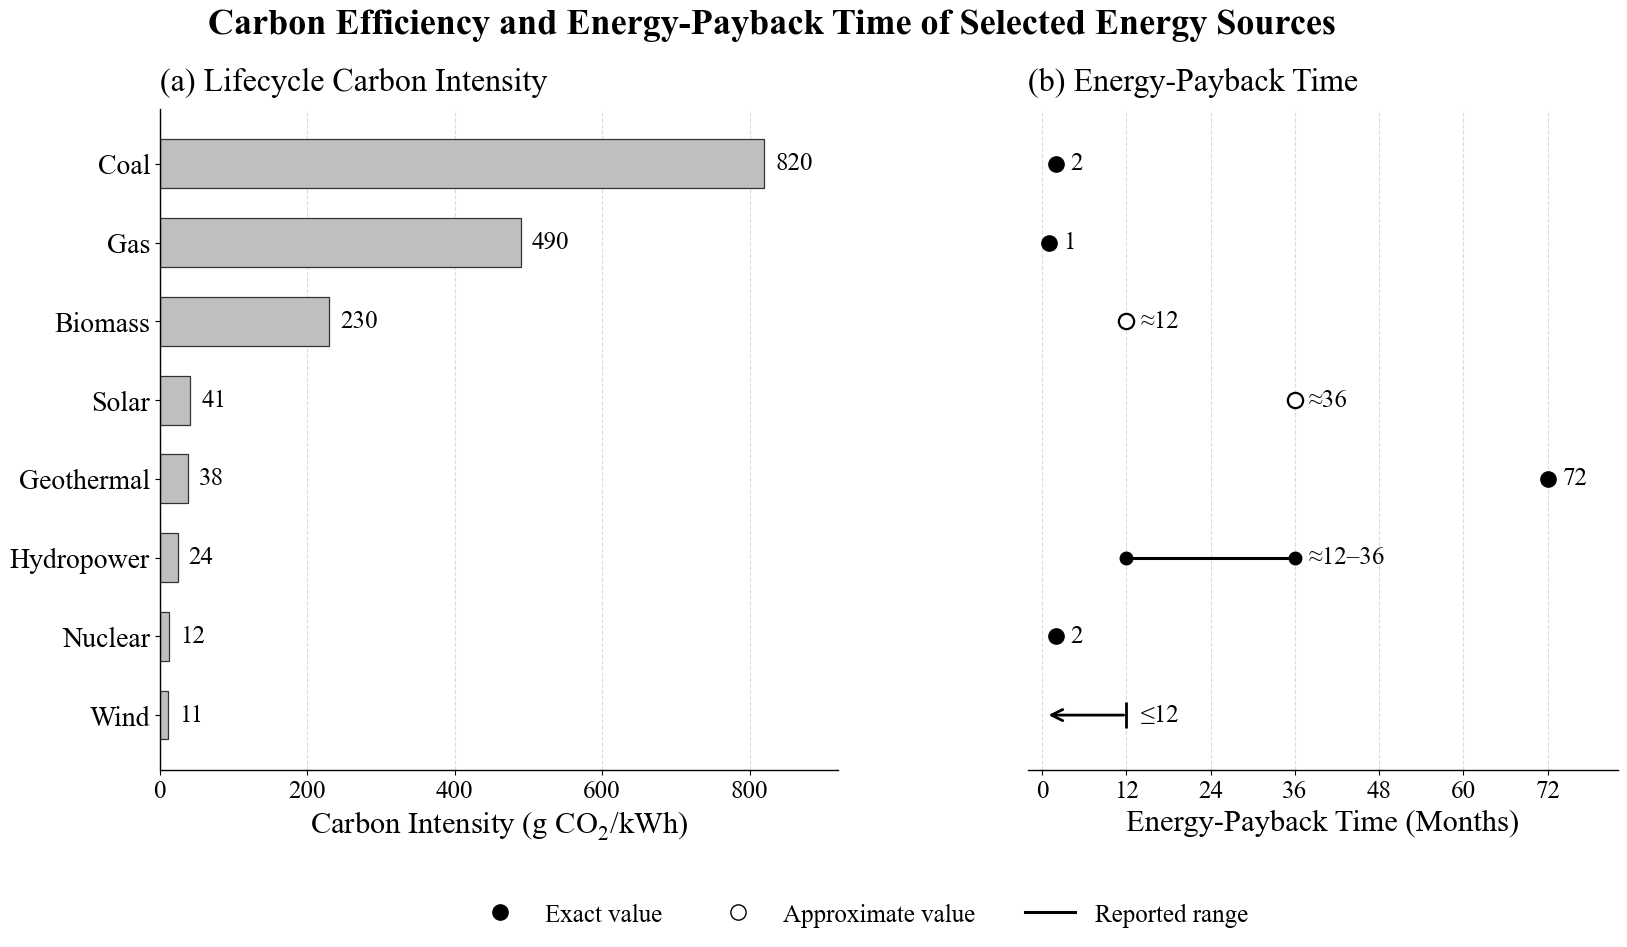

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

# --------------------------------------------------
# Data: Carbon Efficiency of Various Energy Sources
# --------------------------------------------------
sources = [
    "Coal", "Gas", "Biomass", "Solar",
    "Geothermal", "Hydropower", "Nuclear", "Wind"
]

carbon_intensity = np.array([820, 490, 230, 41, 38, 24, 12, 11])

# Energy-payback data
# Type: exact / approximate / range / upper_limit
payback_data = {
    "Coal":        {"type": "exact",        "value": 2,  "label": "2"},
    "Gas":         {"type": "exact",        "value": 1,  "label": "1"},
    "Biomass":     {"type": "approximate",  "value": 12, "label": "≈12"},
    "Solar":       {"type": "approximate",  "value": 36, "label": "≈36"},
    "Geothermal":  {"type": "exact",        "value": 72, "label": "72"},
    "Hydropower":  {"type": "range",        "low": 12, "high": 36, "label": "≈12–36"},
    "Nuclear":     {"type": "exact",        "value": 2,  "label": "2"},
    "Wind":        {"type": "upper_limit",  "value": 12, "label": "≤12"},
}

# --------------------------------------------------
# Times New Roman + Large Font Settings
# --------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 20,
    "axes.labelsize": 22,
    "axes.titlesize": 23,
    "axes.linewidth": 1.0,
    "xtick.labelsize": 18,
    "ytick.labelsize": 20,
    "legend.fontsize": 18,

    # Times New Roman for mathematical text, including CO₂
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman:bold",
})

y = np.arange(len(sources))

# --------------------------------------------------
# Create Figure
# --------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    ncols=2,
    figsize=(18, 10),
    sharey=True,
    gridspec_kw={"width_ratios": [1.15, 1]}
)

fig.subplots_adjust(
    left=0.16,
    right=0.97,
    top=0.85,
    bottom=0.19,
    wspace=0.30
)

# ==================================================
# Panel A: Carbon Intensity
# ==================================================
bars = ax1.barh(
    y,
    carbon_intensity,
    height=0.62,
    color="0.75",
    edgecolor="0.20",
    linewidth=0.9
)

ax1.set_yticks(y)
ax1.set_yticklabels(sources, fontname="Times New Roman")
ax1.invert_yaxis()

ax1.set_xlim(0, 920)
ax1.xaxis.set_major_locator(MultipleLocator(200))

ax1.set_xlabel(
    r"Carbon Intensity (g CO$_2$/kWh)",
    fontname="Times New Roman"
)

# Not bold
ax1.set_title(
    "(a) Lifecycle Carbon Intensity",
    loc="left",
    pad=14,
    fontweight="normal",
    fontname="Times New Roman"
)

ax1.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.45)
ax1.set_axisbelow(True)

# Carbon intensity value labels
for bar, value in zip(bars, carbon_intensity):
    ax1.text(
        value + 15,
        bar.get_y() + bar.get_height() / 2,
        f"{value}",
        va="center",
        ha="left",
        fontsize=18,
        fontname="Times New Roman"
    )

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# ==================================================
# Panel B: Energy-Payback Time
# ==================================================
ax2.set_xlim(-2, 82)
ax2.xaxis.set_major_locator(MultipleLocator(12))

ax2.set_xlabel(
    "Energy-Payback Time (Months)",
    fontname="Times New Roman"
)

# Not bold
ax2.set_title(
    "(b) Energy-Payback Time",
    loc="left",
    pad=14,
    fontweight="normal",
    fontname="Times New Roman"
)

ax2.grid(axis="x", linestyle="--", linewidth=0.8, alpha=0.45)
ax2.set_axisbelow(True)

for i, source in enumerate(sources):
    item = payback_data[source]
    value_type = item["type"]

    # Exact value
    if value_type == "exact":
        ax2.plot(
            item["value"],
            i,
            marker="o",
            markersize=11,
            color="black"
        )

        ax2.text(
            item["value"] + 2,
            i,
            item["label"],
            va="center",
            ha="left",
            fontsize=18,
            fontname="Times New Roman"
        )

    # Approximate value
    elif value_type == "approximate":
        ax2.plot(
            item["value"],
            i,
            marker="o",
            markersize=11,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.6
        )

        ax2.text(
            item["value"] + 2,
            i,
            item["label"],
            va="center",
            ha="left",
            fontsize=18,
            fontname="Times New Roman"
        )

    # Range value
    elif value_type == "range":
        ax2.hlines(
            y=i,
            xmin=item["low"],
            xmax=item["high"],
            color="black",
            linewidth=2.2
        )

        ax2.plot(
            [item["low"], item["high"]],
            [i, i],
            marker="o",
            linestyle="None",
            markersize=9,
            color="black"
        )

        ax2.text(
            item["high"] + 2,
            i,
            item["label"],
            va="center",
            ha="left",
            fontsize=18,
            fontname="Times New Roman"
        )

    # Upper-limit value
    elif value_type == "upper_limit":
        ax2.annotate(
            "",
            xy=(0.5, i),
            xytext=(item["value"], i),
            arrowprops=dict(
                arrowstyle="->",
                linewidth=2.0,
                color="black"
            )
        )

        ax2.plot(
            item["value"],
            i,
            marker="|",
            markersize=19,
            markeredgewidth=2.0,
            color="black"
        )

        ax2.text(
            item["value"] + 2,
            i,
            item["label"],
            va="center",
            ha="left",
            fontsize=18,
            fontname="Times New Roman"
        )

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.tick_params(axis="y", left=False, labelleft=False)

# --------------------------------------------------
# Legend
# --------------------------------------------------
legend_items = [
    Line2D(
        [0], [0],
        marker="o",
        color="black",
        linestyle="None",
        markersize=11,
        label="Exact value"
    ),
    Line2D(
        [0], [0],
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        color="black",
        linestyle="None",
        markersize=11,
        label="Approximate value"
    ),
    Line2D(
        [0], [0],
        color="black",
        linewidth=2.2,
        label="Reported range"
    ),
]

fig.legend(
    handles=legend_items,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.55, 0.01),
    prop={"family": "Times New Roman", "size": 18}
)

# --------------------------------------------------
# Overall Title
# --------------------------------------------------
fig.suptitle(
    "Carbon Efficiency and Energy-Payback Time of Selected Energy Sources",
    fontsize=26,
    fontweight="bold",
    fontname="Times New Roman",
    y=0.95
)

# --------------------------------------------------
# Save Files
# --------------------------------------------------
plt.savefig(
    "Figure_Carbon_Efficiency_Energy_Sources.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Figure_Carbon_Efficiency_Energy_Sources.pdf",
    bbox_inches="tight"
)

plt.show()

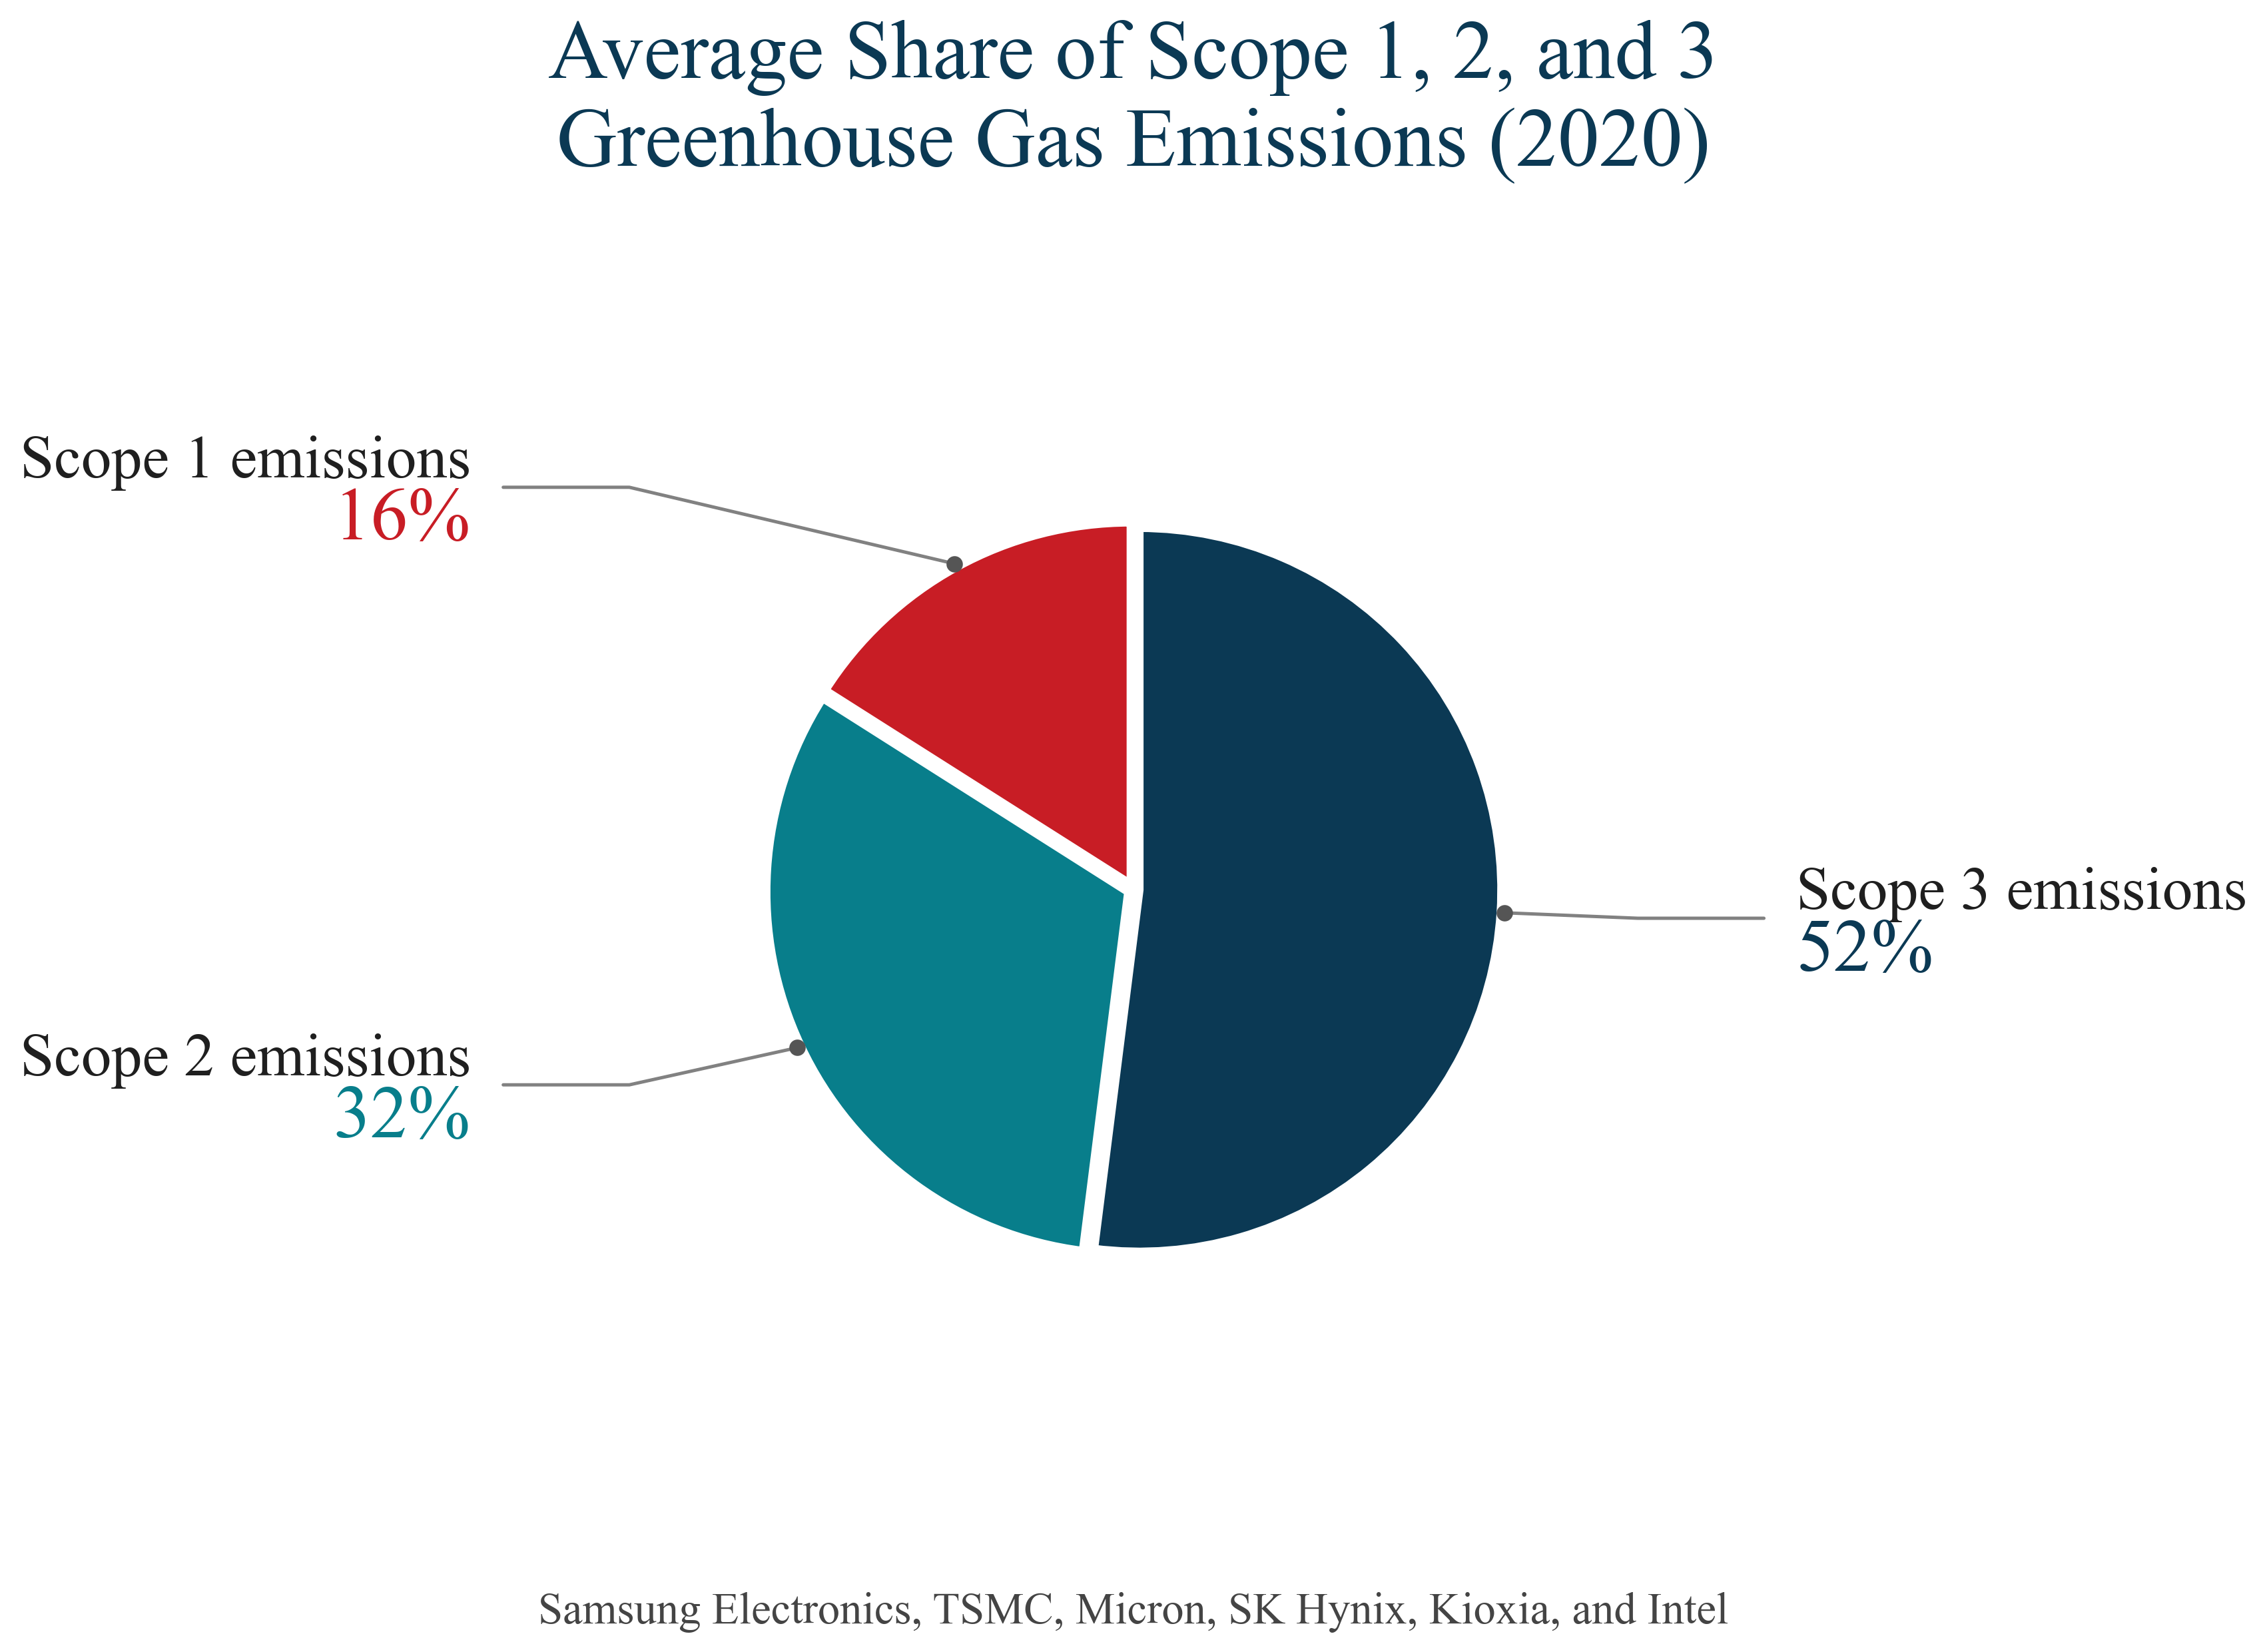

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"]
})

labels = ["Scope 3 emissions", "Scope 2 emissions", "Scope 1 emissions"]
values = np.array([52, 32, 16])
colors = ["#0B3954", "#087E8B", "#C81D25"]
explode = [0.018] * len(values)

fig, ax = plt.subplots(figsize=(14, 9), dpi=300)
fig.patch.set_facecolor("none")
ax.set_facecolor("none")

wedges, _ = ax.pie(
    values,
    startangle=90,
    counterclock=False,
    colors=colors,
    radius=1.12,
    explode=explode,
    wedgeprops=dict(edgecolor="white", linewidth=3)
)

label_data = []
for i, wedge in enumerate(wedges):
    angle = (wedge.theta1 + wedge.theta2) / 2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))
    side = "right" if x >= 0 else "left"
    label_data.append({
        "index": i,
        "x": x,
        "y": y,
        "side": side,
        "label_y": y * 1.42
    })

for side in ["left", "right"]:
    side_labels = [item for item in label_data if item["side"] == side]
    side_labels.sort(key=lambda item: item["label_y"], reverse=True)
    min_gap = 0.42

    for j in range(1, len(side_labels)):
        previous_y = side_labels[j - 1]["label_y"]
        current_y = side_labels[j]["label_y"]
        if previous_y - current_y < min_gap:
            side_labels[j]["label_y"] = previous_y - min_gap

for item in label_data:
    i = item["index"]
    x = item["x"]
    y = item["y"]

    text_x = 2.05 if item["side"] == "right" else -2.05
    text_align = "left" if item["side"] == "right" else "right"

    anchor_x = x * 1.15
    anchor_y = y * 1.15
    elbow_x = 1.56 if item["side"] == "right" else -1.56
    line_end_x = text_x - 0.10 if item["side"] == "right" else text_x + 0.10

    ax.plot(
        [anchor_x, elbow_x, line_end_x],
        [anchor_y, item["label_y"], item["label_y"]],
        color="#6B6B6B",
        lw=1.2,
        alpha=0.85,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=2
    )

    ax.scatter(anchor_x, anchor_y, s=24, color="#555555", zorder=3)

    ax.text(
        text_x,
        item["label_y"] + 0.075,
        labels[i],
        ha=text_align,
        va="center",
        fontsize=22,
        color="#1F1F1F",
        zorder=4
    )

    ax.text(
        text_x,
        item["label_y"] - 0.105,
        f"{values[i]}%",
        ha=text_align,
        va="center",
        fontsize=27,
        color=colors[i],
        zorder=4
    )

ax.set_title(
    "Average Share of Scope 1, 2, and 3\nGreenhouse Gas Emissions (2020)",
    fontsize=30,
    color="#0B3954",
    pad=28
)

fig.text(
    0.5,
    0.075,
    "Samsung Electronics, TSMC, Micron, SK Hynix, Kioxia, and Intel",
    ha="center",
    fontsize=16,
    color="#444444"
)

ax.set_aspect("equal")
ax.set_xlim(-3.1, 3.1)
ax.set_ylim(-2.0, 2.0)

plt.tight_layout(rect=[0, 0.09, 1, 1])

fig.savefig(
    "ghg_emissions_scope_share_2020.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.15
)

plt.show()


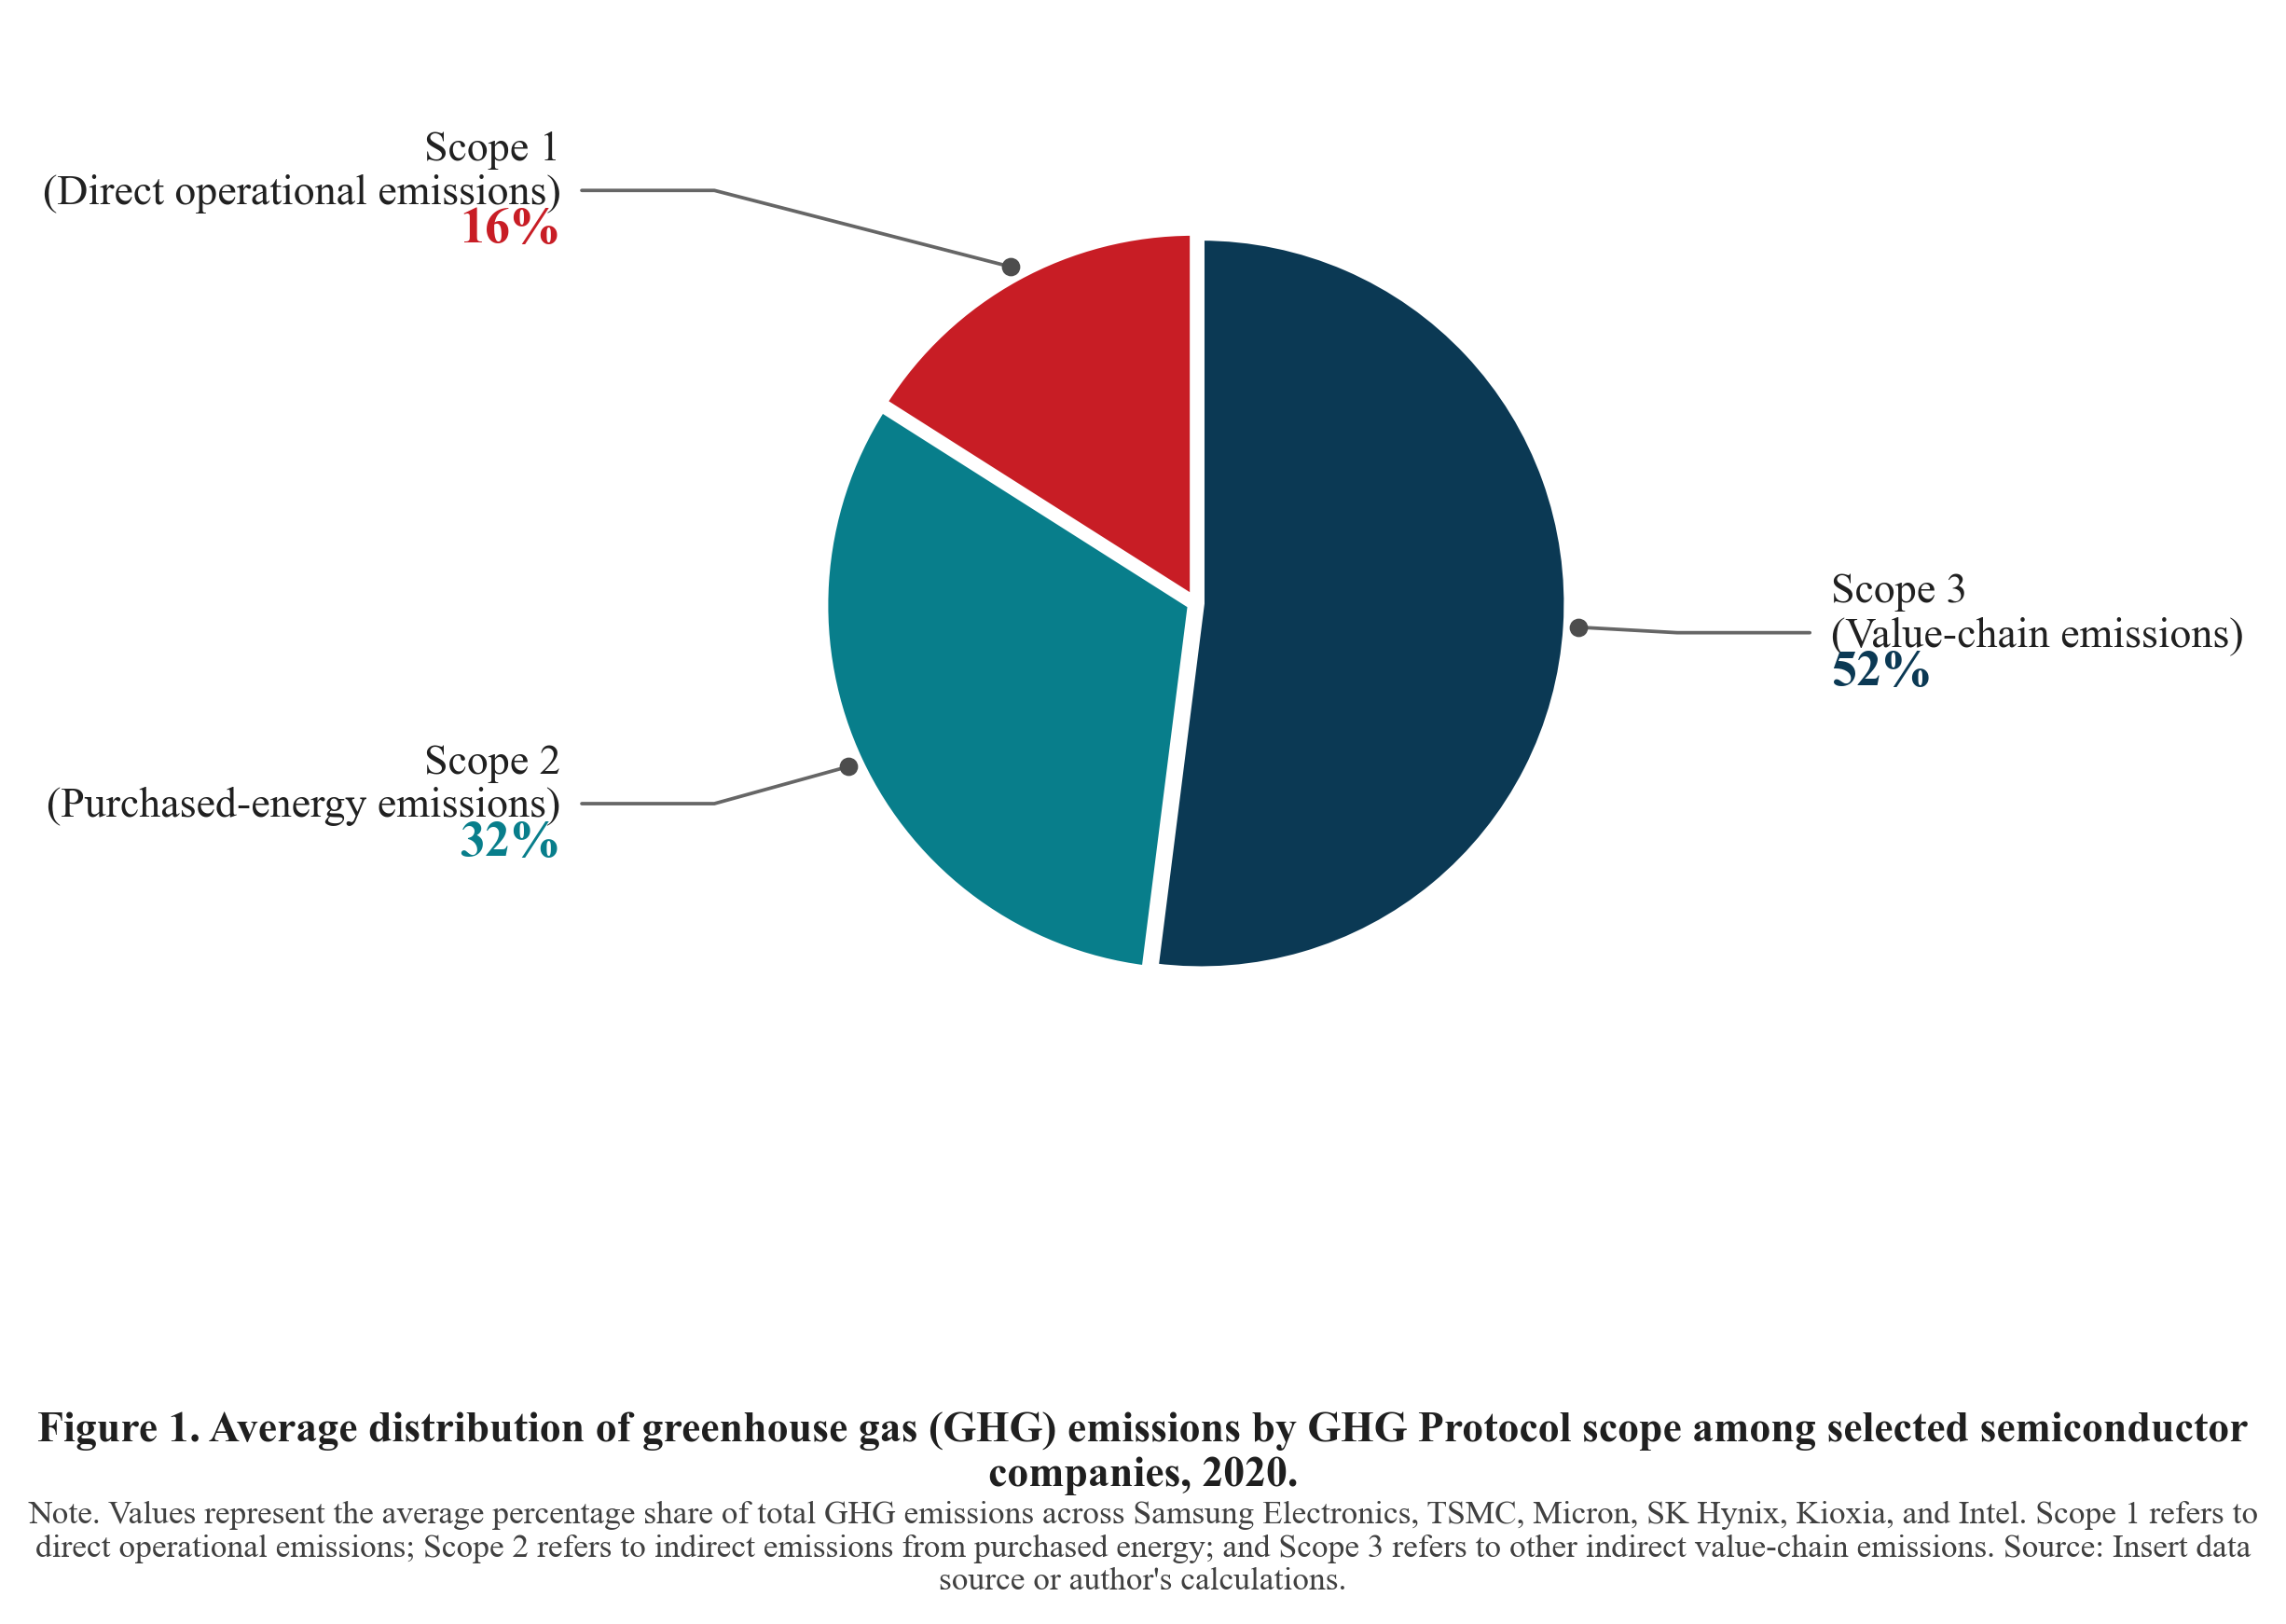

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Journal-style typography
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 11
})

# Data
labels = [
    "Scope 3\n(Value-chain emissions)",
    "Scope 2\n(Purchased-energy emissions)",
    "Scope 1\n(Direct operational emissions)"
]

values = np.array([52, 32, 16])
colors = ["#0B3954", "#087E8B", "#C81D25"]
explode = [0.015] * len(values)

# Create figure
fig, ax = plt.subplots(figsize=(8.2, 6.4), dpi=300)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

wedges, _ = ax.pie(
    values,
    startangle=90,
    counterclock=False,
    colors=colors,
    radius=1.05,
    explode=explode,
    wedgeprops=dict(edgecolor="white", linewidth=1.8)
)

# Determine label placement
label_data = []

for i, wedge in enumerate(wedges):
    angle = (wedge.theta1 + wedge.theta2) / 2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))

    side = "right" if x >= 0 else "left"

    label_data.append({
        "index": i,
        "x": x,
        "y": y,
        "side": side,
        "label_y": y * 1.35
    })

# Prevent label overlap
for side in ["left", "right"]:
    side_labels = [item for item in label_data if item["side"] == side]
    side_labels.sort(key=lambda item: item["label_y"], reverse=True)

    min_gap = 0.34

    for j in range(1, len(side_labels)):
        previous_y = side_labels[j - 1]["label_y"]
        current_y = side_labels[j]["label_y"]

        if previous_y - current_y < min_gap:
            side_labels[j]["label_y"] = previous_y - min_gap

# Add connectors and labels
for item in label_data:
    i = item["index"]
    x = item["x"]
    y = item["y"]

    text_x = 1.82 if item["side"] == "right" else -1.82
    text_align = "left" if item["side"] == "right" else "right"

    anchor_x = x * 1.10
    anchor_y = y * 1.10

    elbow_x = 1.38 if item["side"] == "right" else -1.38
    line_end_x = text_x - 0.06 if item["side"] == "right" else text_x + 0.06

    ax.plot(
        [anchor_x, elbow_x, line_end_x],
        [anchor_y, item["label_y"], item["label_y"]],
        color="#666666",
        lw=0.9,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=2
    )

    ax.scatter(
        anchor_x,
        anchor_y,
        s=14,
        color="#4D4D4D",
        zorder=3
    )

    ax.text(
        text_x,
        item["label_y"] + 0.055,
        labels[i],
        ha=text_align,
        va="center",
        fontsize=11,
        color="#202020",
        linespacing=1.15,
        zorder=4
    )

    ax.text(
        text_x,
        item["label_y"] - 0.115,
        f"{values[i]}%",
        ha=text_align,
        va="center",
        fontsize=13,
        fontweight="bold",
        color=colors[i],
        zorder=4
    )

# Remove axes
ax.set_aspect("equal")
ax.set_xlim(-2.55, 2.55)
ax.set_ylim(-1.65, 1.65)
ax.axis("off")

# Journal-style figure caption
fig.text(
    0.5,
    0.105,
    "Figure 1. Average distribution of greenhouse gas (GHG) emissions by "
    "GHG Protocol scope among selected semiconductor companies, 2020.",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    color="#1F1F1F",
    wrap=True
)

# Research-standard explanatory note
fig.text(
    0.5,
    0.052,
    "Note. Values represent the average percentage share of total GHG emissions "
    "across Samsung Electronics, TSMC, Micron, SK Hynix, Kioxia, and Intel. "
    "Scope 1 refers to direct operational emissions; Scope 2 refers to indirect "
    "emissions from purchased energy; and Scope 3 refers to other indirect "
    "value-chain emissions. Source: Insert data source or author's calculations.",
    ha="center",
    va="center",
    fontsize=8.5,
    color="#404040",
    wrap=True
)

plt.tight_layout(rect=[0, 0.16, 1, 1])

fig.savefig(
    "ghg_emissions_scope_share_2020_journal.png",
    dpi=300,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.12
)

plt.show()

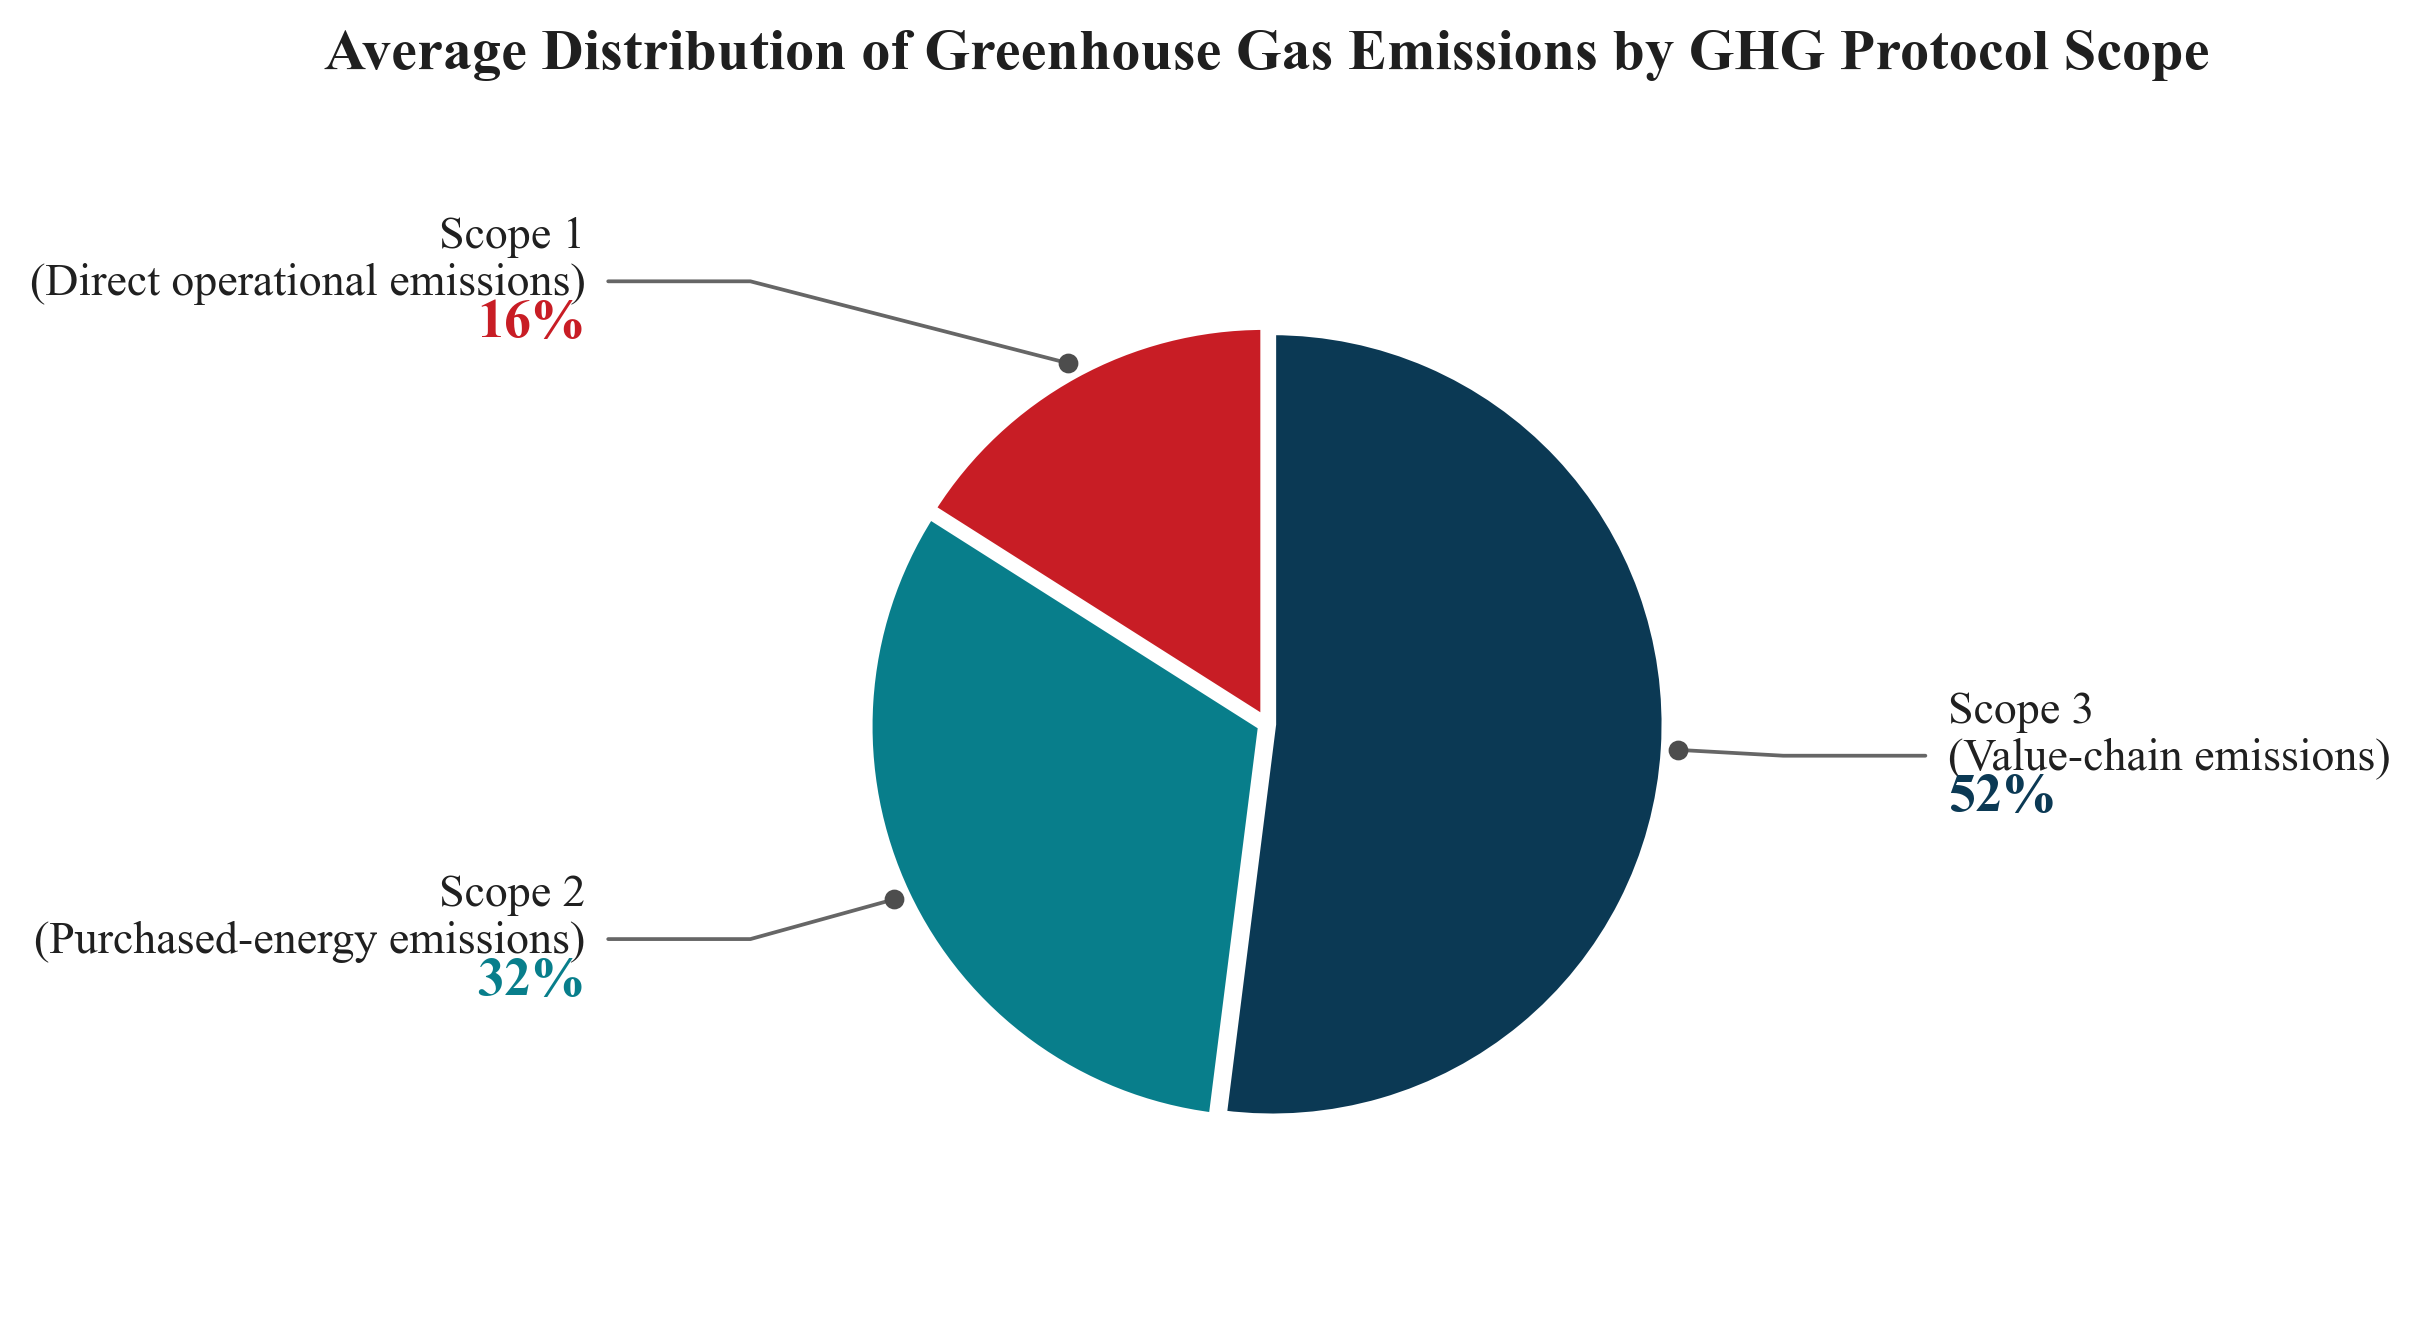

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Journal-style typography
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 11
})

# Data
labels = [
    "Scope 3\n(Value-chain emissions)",
    "Scope 2\n(Purchased-energy emissions)",
    "Scope 1\n(Direct operational emissions)"
]

values = np.array([52, 32, 16])
colors = ["#0B3954", "#087E8B", "#C81D25"]
explode = [0.015] * len(values)

# Create figure
fig, ax = plt.subplots(figsize=(8.2, 6.4), dpi=300)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Pie chart
wedges, _ = ax.pie(
    values,
    startangle=90,
    counterclock=False,
    colors=colors,
    radius=1.05,
    explode=explode,
    wedgeprops=dict(
        edgecolor="white",
        linewidth=1.8
    )
)

# Label positioning data
label_data = []

for i, wedge in enumerate(wedges):
    angle = (wedge.theta1 + wedge.theta2) / 2

    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))

    side = "right" if x >= 0 else "left"

    label_data.append({
        "index": i,
        "x": x,
        "y": y,
        "side": side,
        "label_y": y * 1.35
    })

# Prevent label overlap
for side in ["left", "right"]:
    side_labels = [
        item for item in label_data
        if item["side"] == side
    ]

    side_labels.sort(
        key=lambda item: item["label_y"],
        reverse=True
    )

    min_gap = 0.34

    for j in range(1, len(side_labels)):
        previous_y = side_labels[j - 1]["label_y"]
        current_y = side_labels[j]["label_y"]

        if previous_y - current_y < min_gap:
            side_labels[j]["label_y"] = previous_y - min_gap

# Connector lines and labels
for item in label_data:
    i = item["index"]
    x = item["x"]
    y = item["y"]

    text_x = 1.82 if item["side"] == "right" else -1.82
    text_align = "left" if item["side"] == "right" else "right"

    anchor_x = x * 1.10
    anchor_y = y * 1.10

    elbow_x = 1.38 if item["side"] == "right" else -1.38
    line_end_x = (
        text_x - 0.06
        if item["side"] == "right"
        else text_x + 0.06
    )

    ax.plot(
        [anchor_x, elbow_x, line_end_x],
        [anchor_y, item["label_y"], item["label_y"]],
        color="#666666",
        lw=0.9,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=2
    )

    ax.scatter(
        anchor_x,
        anchor_y,
        s=14,
        color="#4D4D4D",
        zorder=3
    )

    ax.text(
        text_x,
        item["label_y"] + 0.055,
        labels[i],
        ha=text_align,
        va="center",
        fontsize=11,
        color="#202020",
        linespacing=1.15,
        zorder=4
    )

    ax.text(
        text_x,
        item["label_y"] - 0.115,
        f"{values[i]}%",
        ha=text_align,
        va="center",
        fontsize=13,
        fontweight="bold",
        color=colors[i],
        zorder=4
    )

# Clean journal-style chart area
ax.set_aspect("equal")
ax.set_xlim(-2.55, 2.55)
ax.set_ylim(-1.55, 1.55)
ax.axis("off")

# Optional top title
ax.set_title(
    "Average Distribution of Greenhouse Gas Emissions by GHG Protocol Scope",
    fontsize=14,
    fontweight="bold",
    color="#1F1F1F",
    pad=18
)

plt.tight_layout()

# Save figure
fig.savefig(
    "ghg_emissions_scope_share_2020.png",
    dpi=300,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.12
)

plt.show()

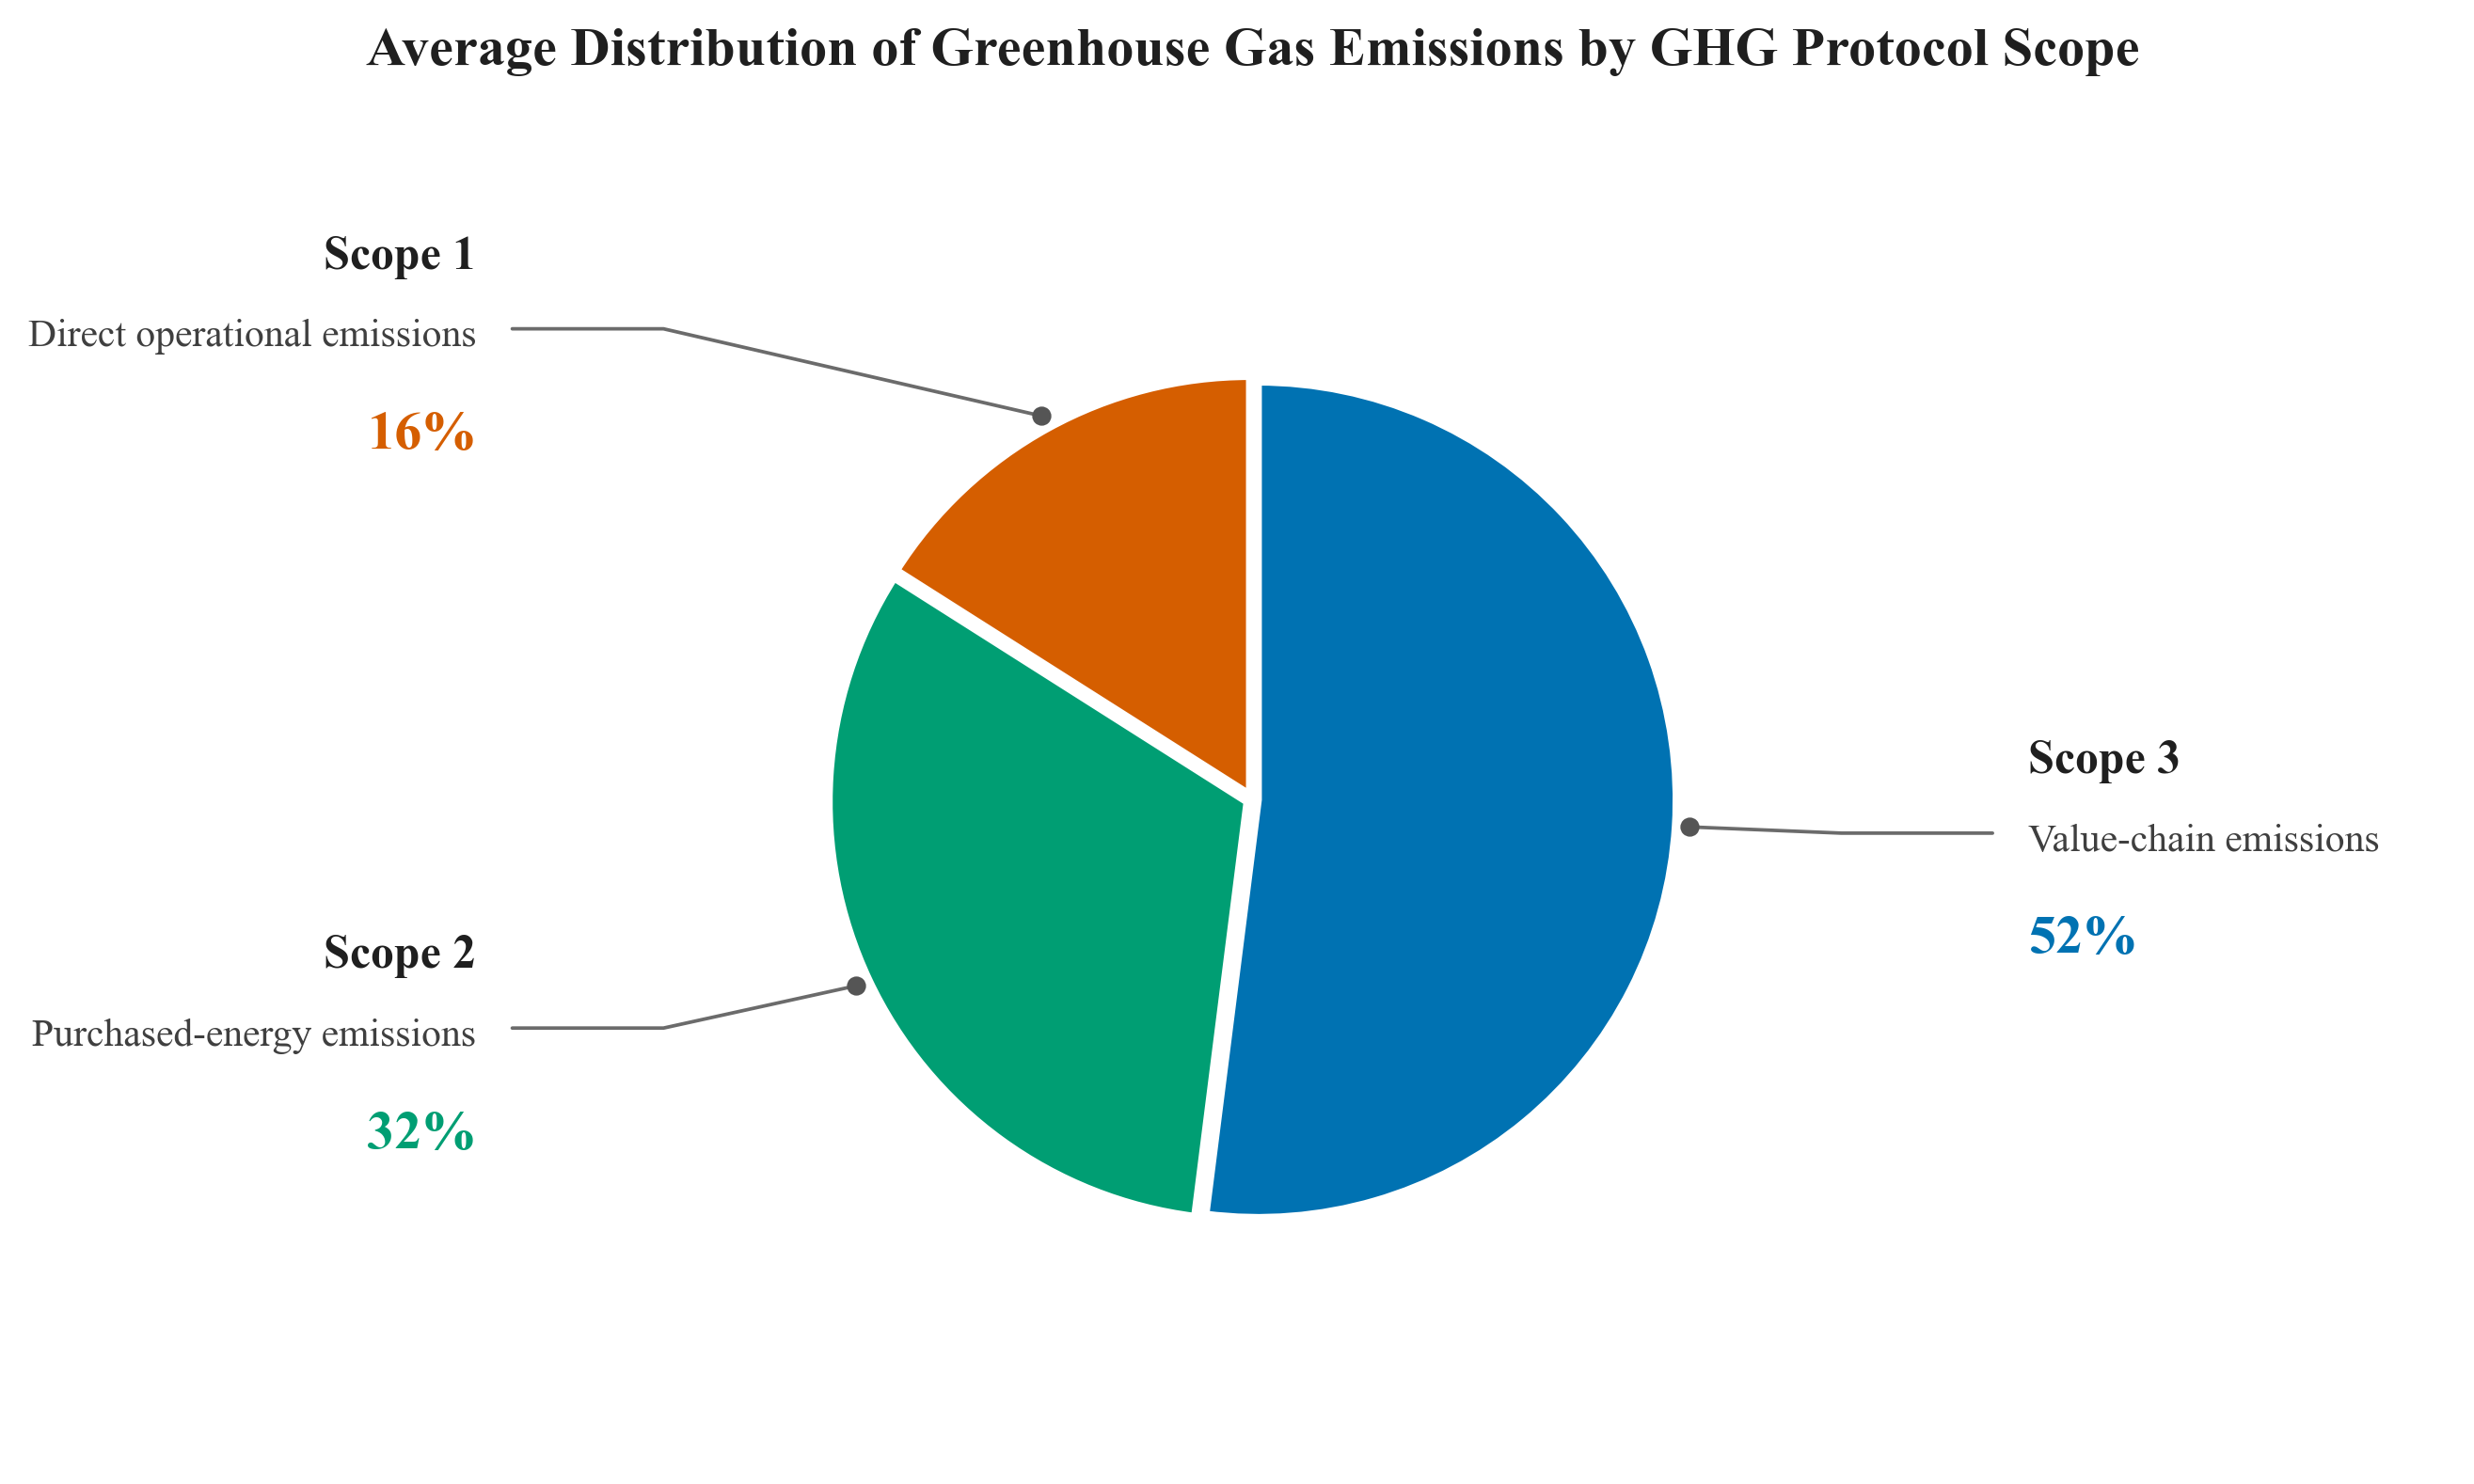

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Journal-style typography
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 11
})

# Data
scope_names = ["Scope 3", "Scope 2", "Scope 1"]

descriptions = [
    "Value-chain emissions",
    "Purchased-energy emissions",
    "Direct operational emissions"
]

values = np.array([52, 32, 16])

# Journal-friendly, colorblind-safe palette
colors = [
    "#0072B2",  # Scope 3 — blue
    "#009E73",  # Scope 2 — green
    "#D55E00"   # Scope 1 — orange
]

explode = [0.015] * len(values)

# Figure
fig, ax = plt.subplots(figsize=(9, 6.6), dpi=300)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Pie chart
wedges, _ = ax.pie(
    values,
    startangle=90,
    counterclock=False,
    colors=colors,
    radius=1.05,
    explode=explode,
    wedgeprops=dict(
        edgecolor="white",
        linewidth=1.8
    )
)

# Collect position data
label_data = []

for i, wedge in enumerate(wedges):
    angle = (wedge.theta1 + wedge.theta2) / 2

    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))

    side = "right" if x >= 0 else "left"

    label_data.append({
        "index": i,
        "x": x,
        "y": y,
        "side": side,
        "label_y": y * 1.35
    })

# Prevent overlap between label groups
for side in ["left", "right"]:
    side_labels = [
        item for item in label_data
        if item["side"] == side
    ]

    side_labels.sort(
        key=lambda item: item["label_y"],
        reverse=True
    )

    min_gap = 0.48

    for j in range(1, len(side_labels)):
        previous_y = side_labels[j - 1]["label_y"]
        current_y = side_labels[j]["label_y"]

        if previous_y - current_y < min_gap:
            side_labels[j]["label_y"] = previous_y - min_gap

# Add connector lines and labels
for item in label_data:
    i = item["index"]

    text_x = 1.95 if item["side"] == "right" else -1.95
    text_align = "left" if item["side"] == "right" else "right"

    anchor_x = item["x"] * 1.10
    anchor_y = item["y"] * 1.10

    elbow_x = 1.48 if item["side"] == "right" else -1.48
    line_end_x = (
        text_x - 0.09
        if item["side"] == "right"
        else text_x + 0.09
    )

    line_y = item["label_y"]

    # Connector line
    ax.plot(
        [anchor_x, elbow_x, line_end_x],
        [anchor_y, line_y, line_y],
        color="#6B6B6B",
        lw=0.9,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=2
    )

    # Connector dot
    ax.scatter(
        anchor_x,
        anchor_y,
        s=15,
        color="#555555",
        zorder=3
    )

    # Scope name
    ax.text(
        text_x,
        line_y + 0.18,
        scope_names[i],
        ha=text_align,
        va="center",
        fontsize=12,
        fontweight="bold",
        color="#1F1F1F",
        zorder=4
    )

    # Description with extra space below Scope name
    ax.text(
        text_x,
        line_y - 0.02,
        descriptions[i],
        ha=text_align,
        va="center",
        fontsize=10,
        color="#3F3F3F",
        zorder=4
    )

    # Percentage with extra space below description
    ax.text(
        text_x,
        line_y - 0.27,
        f"{values[i]}%",
        ha=text_align,
        va="center",
        fontsize=14,
        fontweight="bold",
        color=colors[i],
        zorder=4
    )

# Title
ax.set_title(
    "Average Distribution of Greenhouse Gas Emissions by GHG Protocol Scope",
    fontsize=14,
    fontweight="bold",
    color="#1F1F1F",
    pad=20
)

# Layout
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.65, 1.65)
ax.axis("off")

fig.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.88,
    bottom=0.07
)

# Save
fig.savefig(
    "ghg_emissions_scope_share_2020.png",
    dpi=300,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.10
)

plt.show()

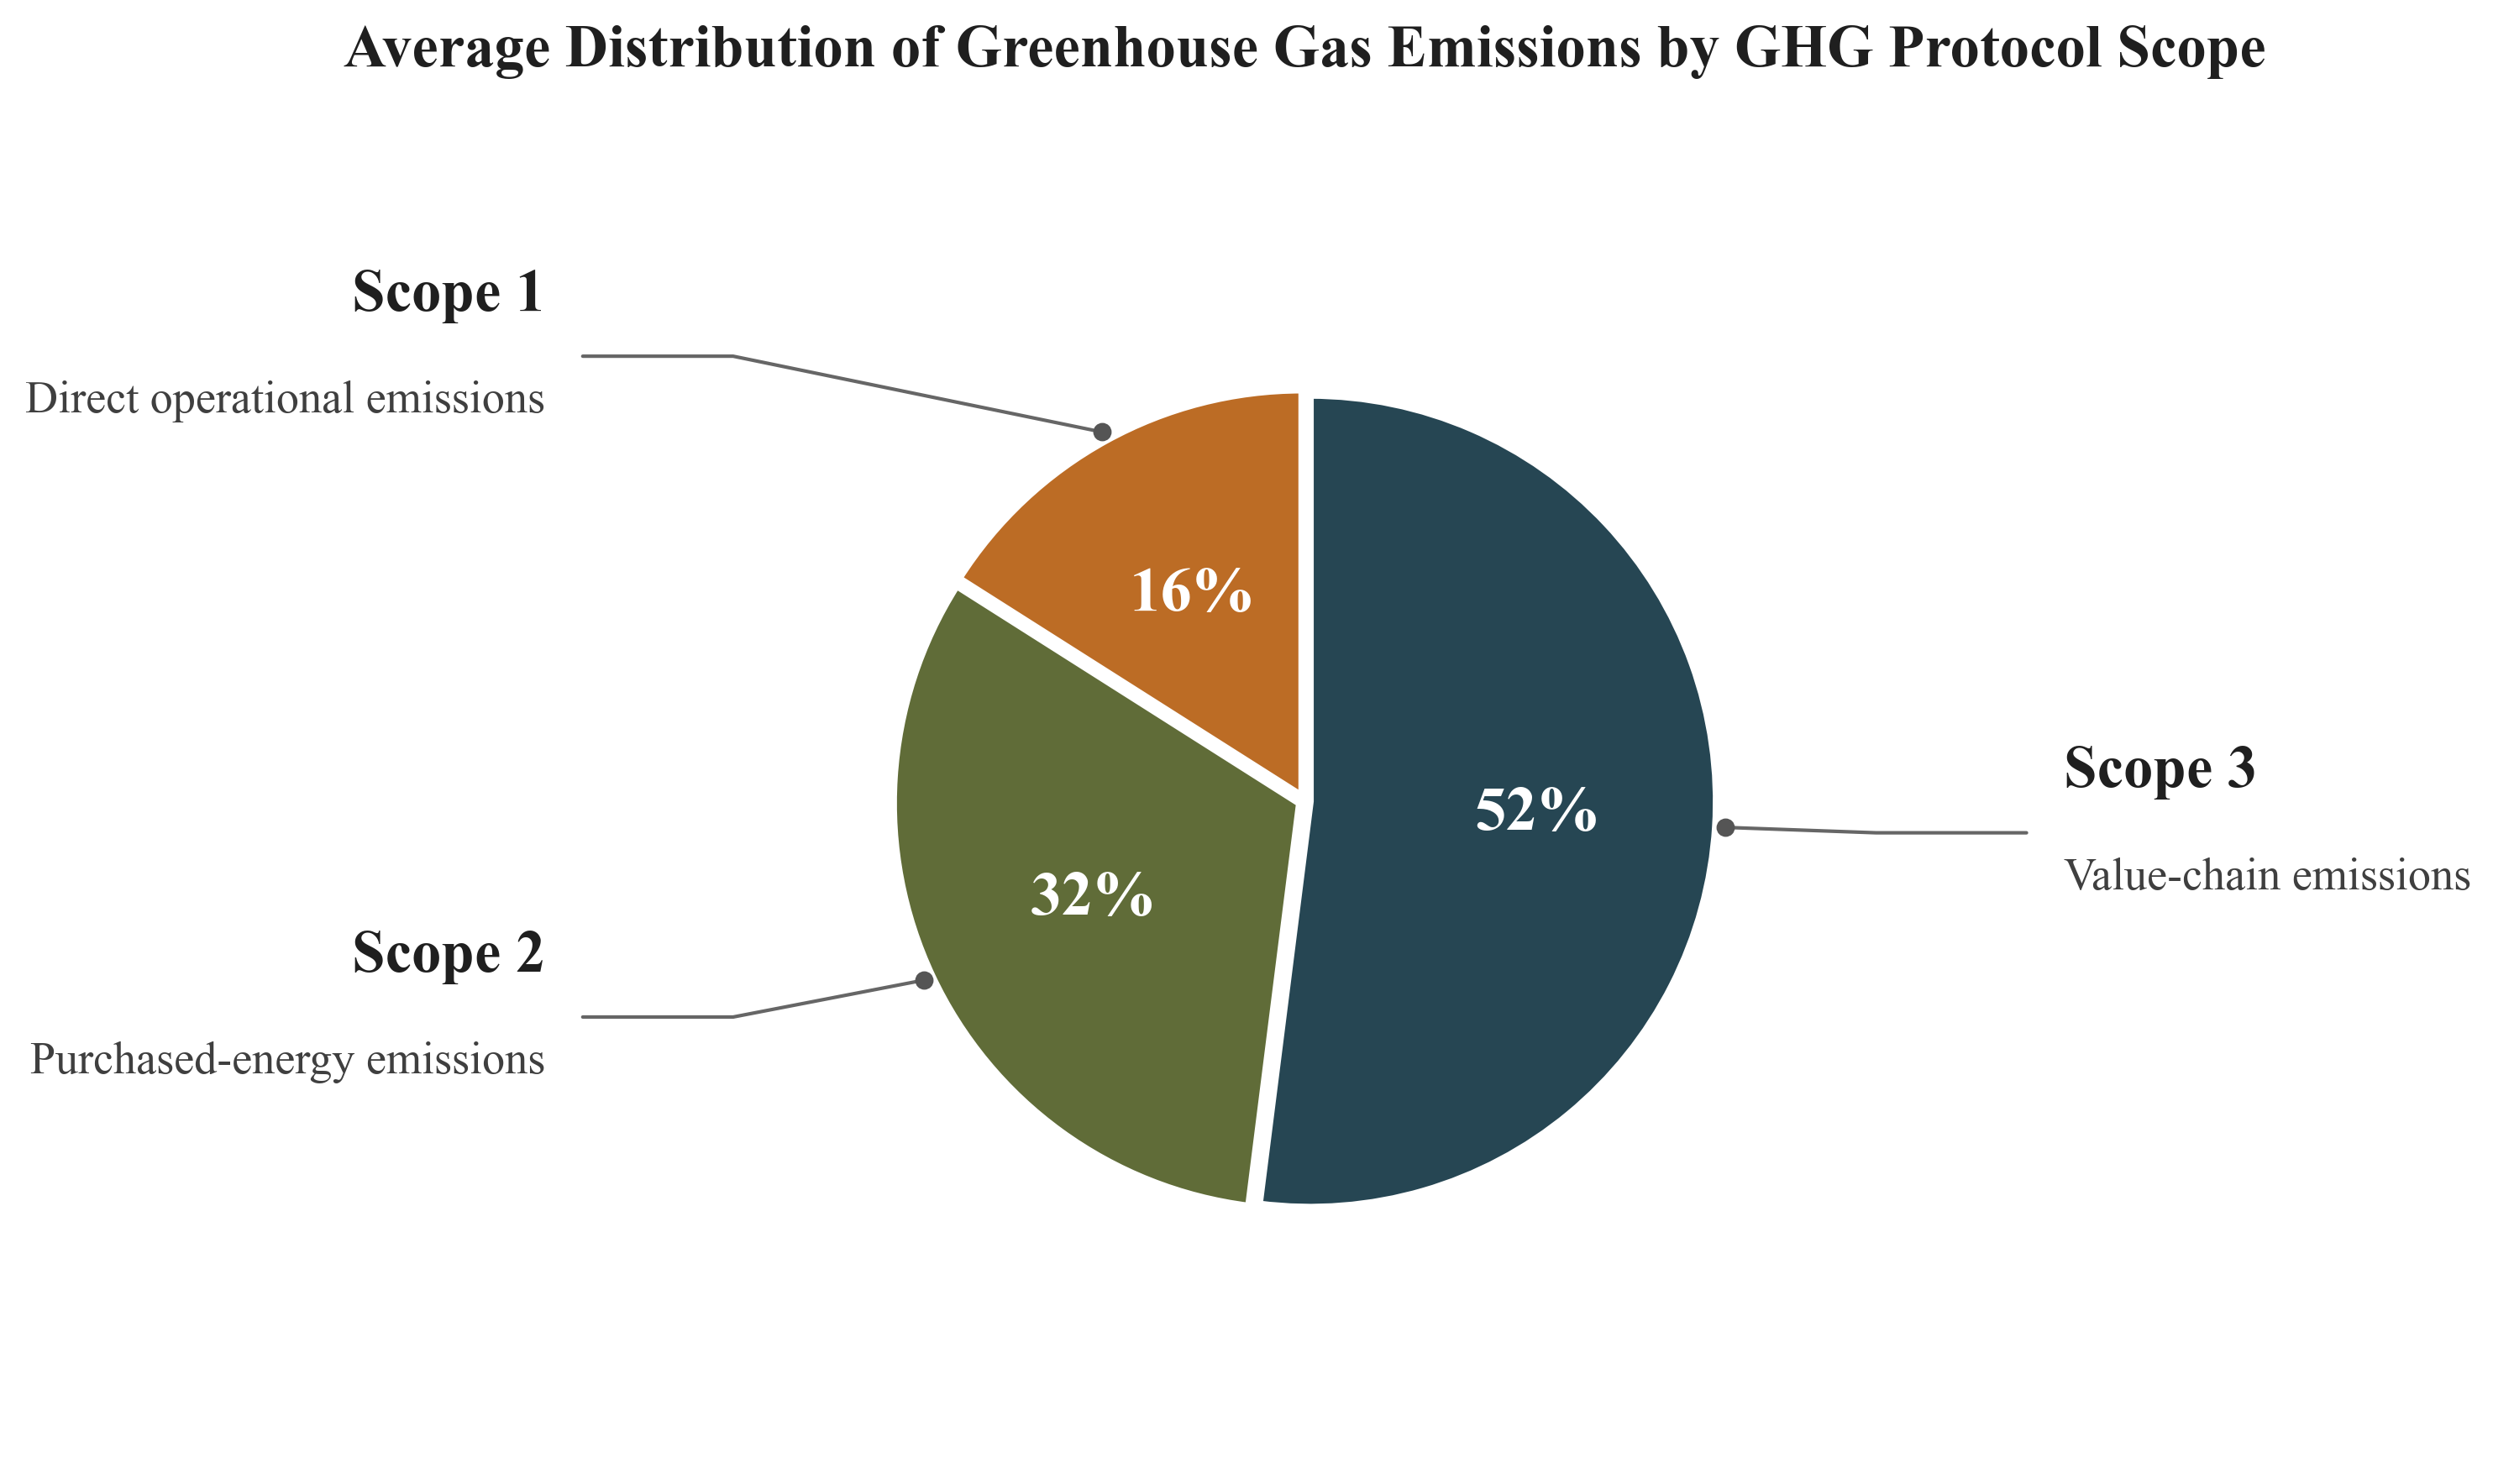

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Use Times New Roman for every chart element
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12
})

# Data
scope_names = ["Scope 3", "Scope 2", "Scope 1"]

descriptions = [
    "Value-chain emissions",
    "Purchased-energy emissions",
    "Direct operational emissions"
]

values = np.array([52, 32, 16])












# Professional, journal-friendly color palette
colors = [
    "#264653",
    "#606C38",
    "#BC6C25"
]








explode = [0.015, 0.015, 0.015]

# Figure setup
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Pie chart
wedges, _ = ax.pie(
    values,
    startangle=90,
    counterclock=False,
    colors=colors,
    radius=1.08,
    explode=explode,
    wedgeprops=dict(
        edgecolor="white",
        linewidth=2
    )
)

# Put percentage values inside the pie slices
for i, wedge in enumerate(wedges):
    angle = (wedge.theta1 + wedge.theta2) / 2

    x = 0.62 * np.cos(np.deg2rad(angle))
    y = 0.62 * np.sin(np.deg2rad(angle))

    ax.text(
        x,
        y,
        f"{values[i]}%",
        ha="center",
        va="center",
        fontsize=18,
        fontweight="bold",
        color="white",
        zorder=5
    )

# Store outside-label positions
label_data = []

for i, wedge in enumerate(wedges):
    angle = (wedge.theta1 + wedge.theta2) / 2

    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))

    side = "right" if x >= 0 else "left"

    label_data.append({
        "index": i,
        "x": x,
        "y": y,
        "side": side,
        "label_y": y * 1.35
    })

# Avoid label overlap
for side in ["left", "right"]:
    side_labels = [
        item for item in label_data
        if item["side"] == side
    ]

    side_labels.sort(
        key=lambda item: item["label_y"],
        reverse=True
    )

    min_gap = 0.52

    for j in range(1, len(side_labels)):
        previous_y = side_labels[j - 1]["label_y"]
        current_y = side_labels[j]["label_y"]

        if previous_y - current_y < min_gap:
            side_labels[j]["label_y"] = previous_y - min_gap

# Draw connectors and outside labels
for item in label_data:
    i = item["index"]

    text_x = 2.02 if item["side"] == "right" else -2.02
    text_align = "left" if item["side"] == "right" else "right"

    anchor_x = item["x"] * 1.12
    anchor_y = item["y"] * 1.12

    elbow_x = 1.52 if item["side"] == "right" else -1.52
    line_end_x = (
        text_x - 0.10
        if item["side"] == "right"
        else text_x + 0.10
    )

    line_y = item["label_y"]

    # Connector line
    ax.plot(
        [anchor_x, elbow_x, line_end_x],
        [anchor_y, line_y, line_y],
        color="#666666",
        lw=1.0,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=2
    )

    # Connector dot
    ax.scatter(
        anchor_x,
        anchor_y,
        s=18,
        color="#555555",
        zorder=3
    )

    # Large Scope label
    ax.text(
        text_x,
        line_y + 0.16,
        scope_names[i],
        ha=text_align,
        va="center",
        fontsize=17,
        fontweight="bold",
        color="#1F1F1F",
        zorder=4
    )

    # Description label
    ax.text(
        text_x,
        line_y - 0.12,
        descriptions[i],
        ha=text_align,
        va="center",
        fontsize=13,
        color="#3F3F3F",
        zorder=4
    )

# Title
ax.set_title(
    "Average Distribution of Greenhouse Gas Emissions by GHG Protocol Scope",
    fontsize=17,
    fontweight="bold",
    color="#1F1F1F",
    pad=22
)

# Final layout
ax.set_aspect("equal")
ax.set_xlim(-3.15, 3.15)
ax.set_ylim(-1.75, 1.75)
ax.axis("off")

fig.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.88,
    bottom=0.06
)

# Save figure
fig.savefig(
    "ghg_emissions_scope_share_2020.png",
    dpi=300,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.12
)

plt.show()

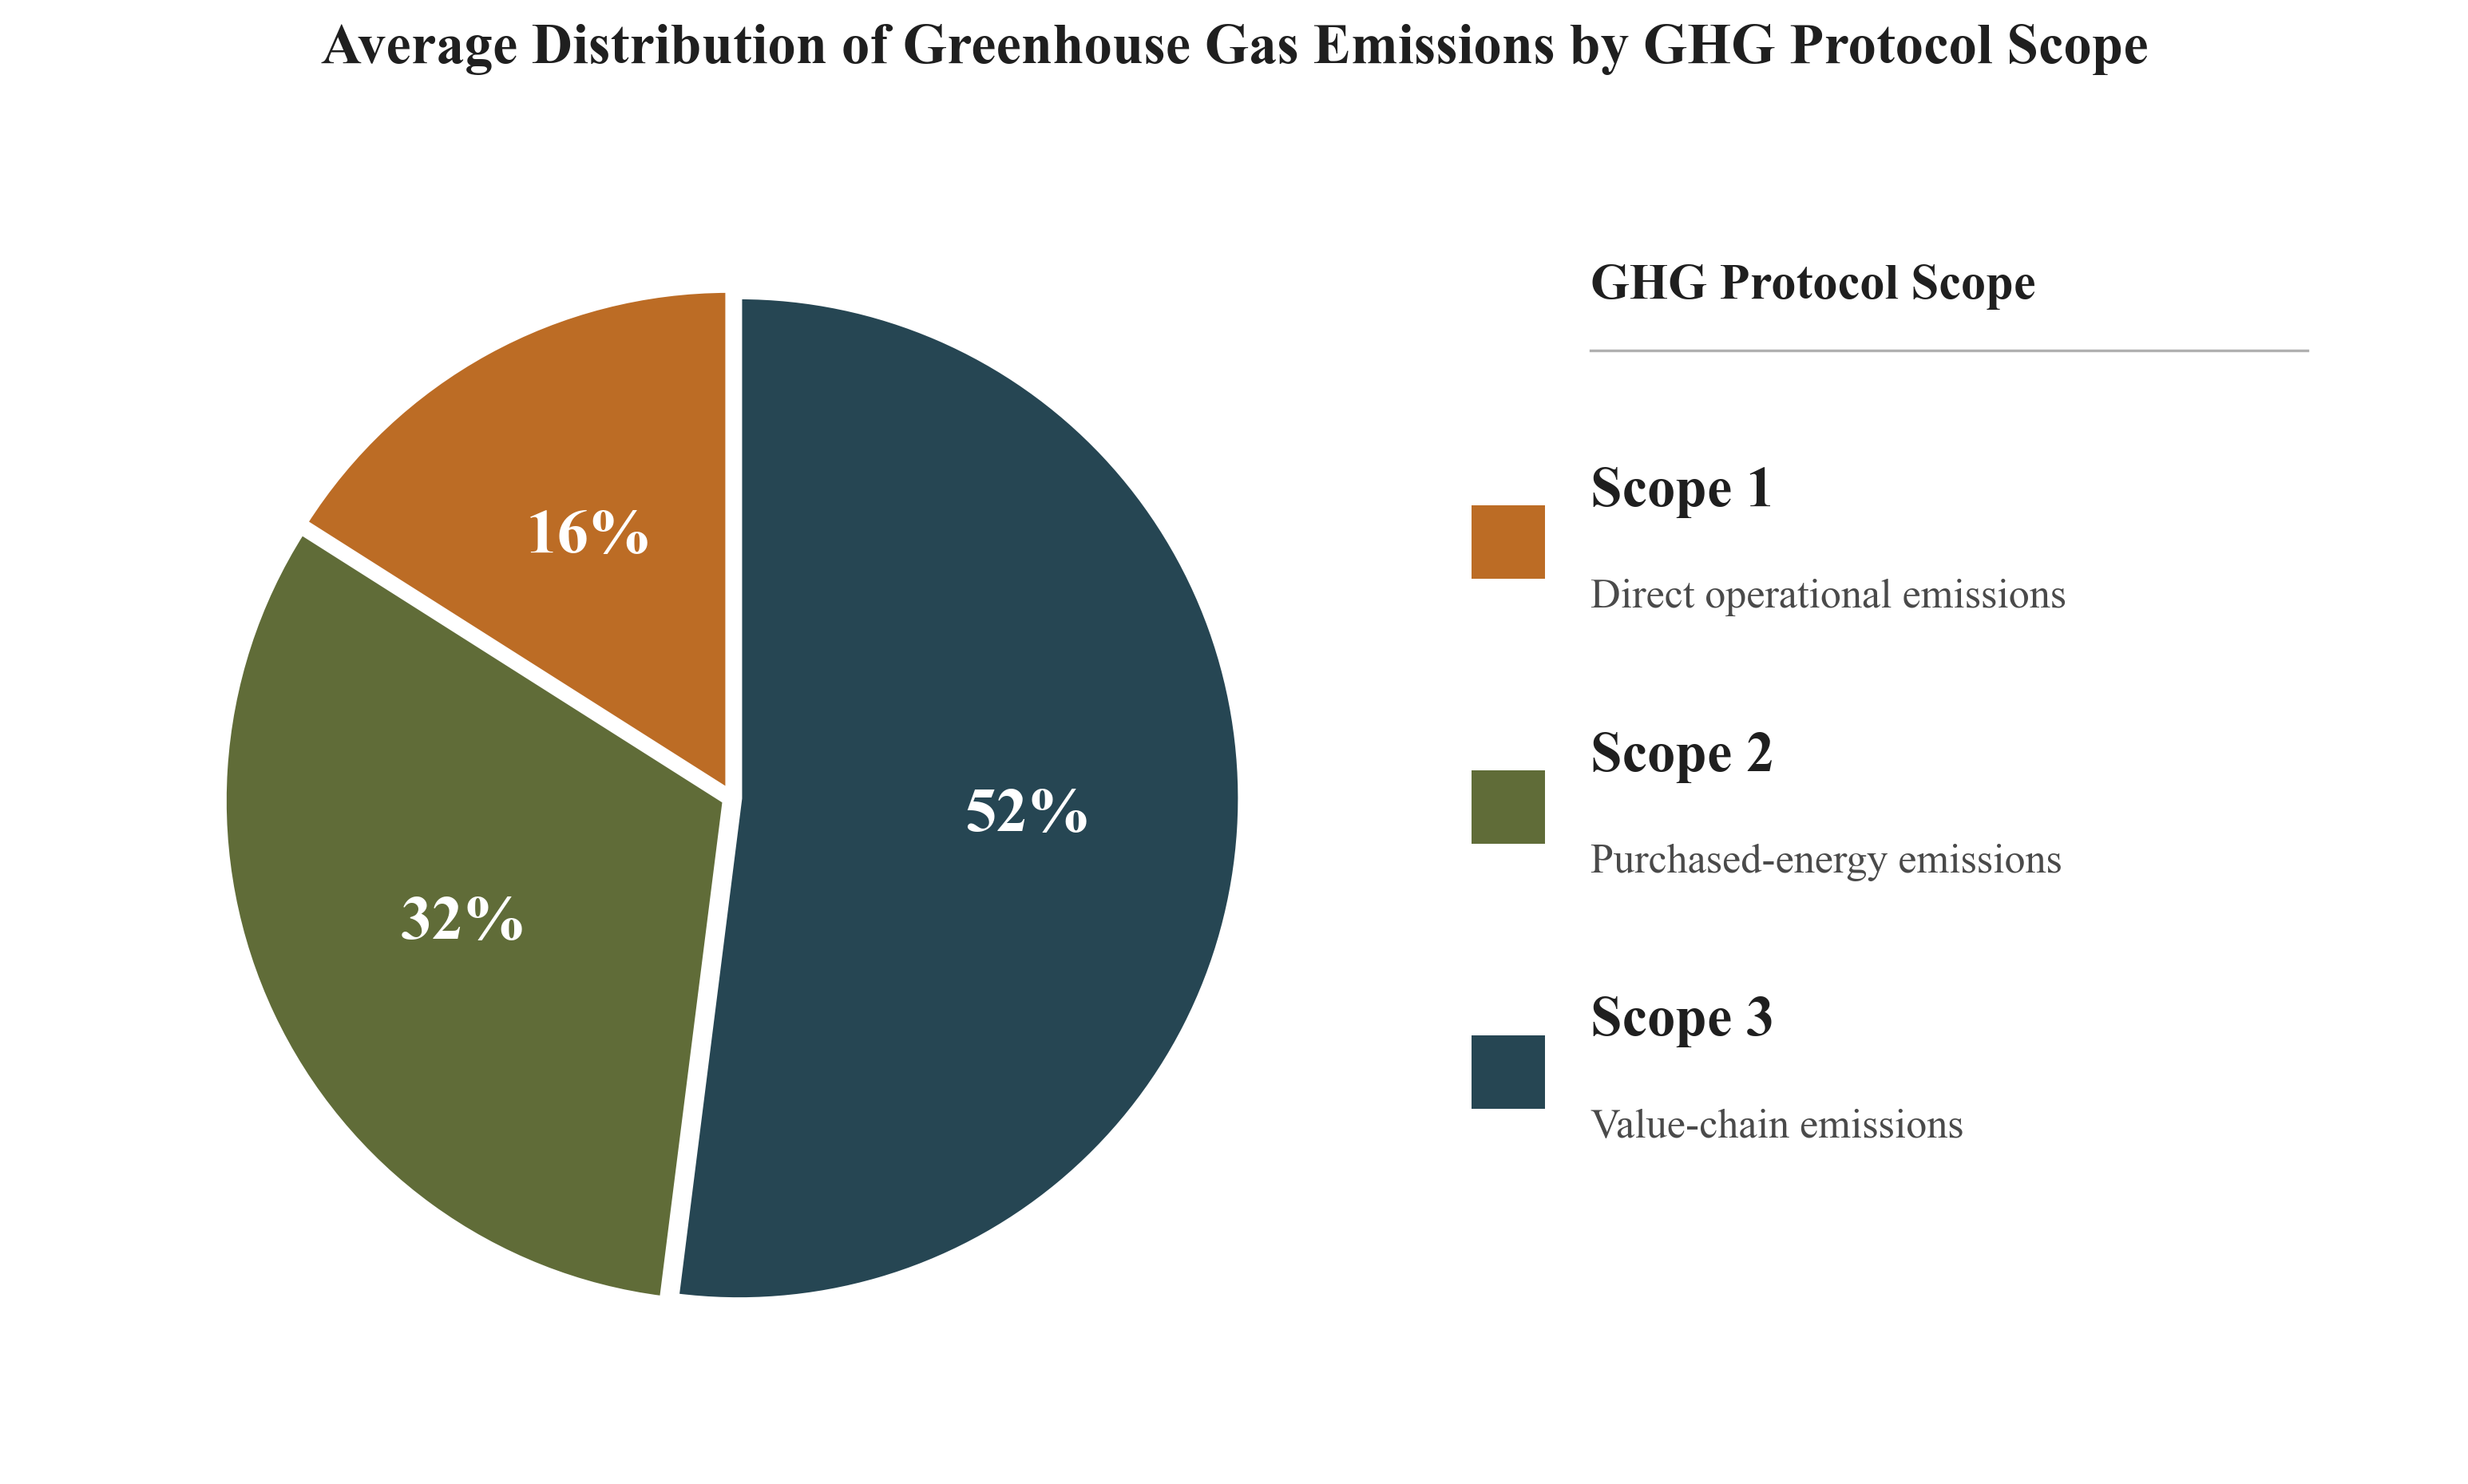

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# ---------------------------------------------------------
# Global font settings: Times New Roman
# ---------------------------------------------------------
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12
})

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
scope_names = ["Scope 3", "Scope 2", "Scope 1"]

descriptions = [
    "Value-chain emissions",
    "Purchased-energy emissions",
    "Direct operational emissions"
]

values = np.array([52, 32, 16])

# Selected palette
colors = [
    "#264653",  # Scope 3
    "#606C38",  # Scope 2
    "#BC6C25"   # Scope 1
]

explode = [0.015, 0.015, 0.015]

# ---------------------------------------------------------
# Figure setup
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 7), dpi=300)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ---------------------------------------------------------
# Pie chart
# ---------------------------------------------------------
wedges, _ = ax.pie(
    values,
    startangle=90,
    counterclock=False,
    colors=colors,
    radius=1.10,
    explode=explode,
    wedgeprops=dict(
        edgecolor="white",
        linewidth=2.0
    )
)

# ---------------------------------------------------------
# Percentage labels inside pie slices
# ---------------------------------------------------------
for i, wedge in enumerate(wedges):
    angle = (wedge.theta1 + wedge.theta2) / 2

    x = 0.65 * np.cos(np.deg2rad(angle))
    y = 0.65 * np.sin(np.deg2rad(angle))

    ax.text(
        x,
        y,
        f"{values[i]}%",
        ha="center",
        va="center",
        fontsize=19,
        fontweight="bold",
        color="white",
        zorder=5
    )

# ---------------------------------------------------------
# Structured right-side scope denotation panel
# ---------------------------------------------------------
panel_x = 1.65
square_x = 1.62
text_x = 1.88

# Header
ax.text(
    text_x,
    1.12,
    "GHG Protocol Scope",
    ha="left",
    va="center",
    fontsize=15,
    fontweight="bold",
    color="#1F1F1F"
)

# Small divider below header
ax.plot(
    [text_x, 3.45],
    [0.98, 0.98],
    color="#B0B0B0",
    lw=0.8
)

# Ordered panel: Scope 1, Scope 2, Scope 3
panel_items = [
    {
        "scope": "Scope 1",
        "description": "Direct operational emissions",
        "color": "#BC6C25",
        "y": 0.60
    },
    {
        "scope": "Scope 2",
        "description": "Purchased-energy emissions",
        "color": "#606C38",
        "y": 0.02
    },
    {
        "scope": "Scope 3",
        "description": "Value-chain emissions",
        "color": "#264653",
        "y": -0.56
    }
]

for item in panel_items:
    # Colored square marker
    marker = Rectangle(
        (square_x, item["y"] - 0.12),
        0.16,
        0.16,
        facecolor=item["color"],
        edgecolor="none",
        zorder=4
    )

    ax.add_patch(marker)

    # Scope title
    ax.text(
        text_x,
        item["y"] + 0.07,
        item["scope"],
        ha="left",
        va="center",
        fontsize=17,
        fontweight="bold",
        color="#1F1F1F",
        zorder=4
    )

    # Scope description
    ax.text(
        text_x,
        item["y"] - 0.16,
        item["description"],
        ha="left",
        va="center",
        fontsize=12.5,
        color="#4A4A4A",
        zorder=4
    )

# ---------------------------------------------------------
# Title
# ---------------------------------------------------------
ax.set_title(
    "Average Distribution of Greenhouse Gas Emissions by GHG Protocol Scope",
    fontsize=17,
    fontweight="bold",
    color="#1F1F1F",
    pad=22
)

# ---------------------------------------------------------
# Final layout
# ---------------------------------------------------------
ax.set_aspect("equal")
ax.set_xlim(-1.55, 3.75)
ax.set_ylim(-1.45, 1.45)
ax.axis("off")

fig.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.87,
    bottom=0.08
)

# ---------------------------------------------------------
# Save high-resolution image
# ---------------------------------------------------------
fig.savefig(
    "ghg_emissions_scope_share_2020.png",
    dpi=300,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.12
)

plt.show()

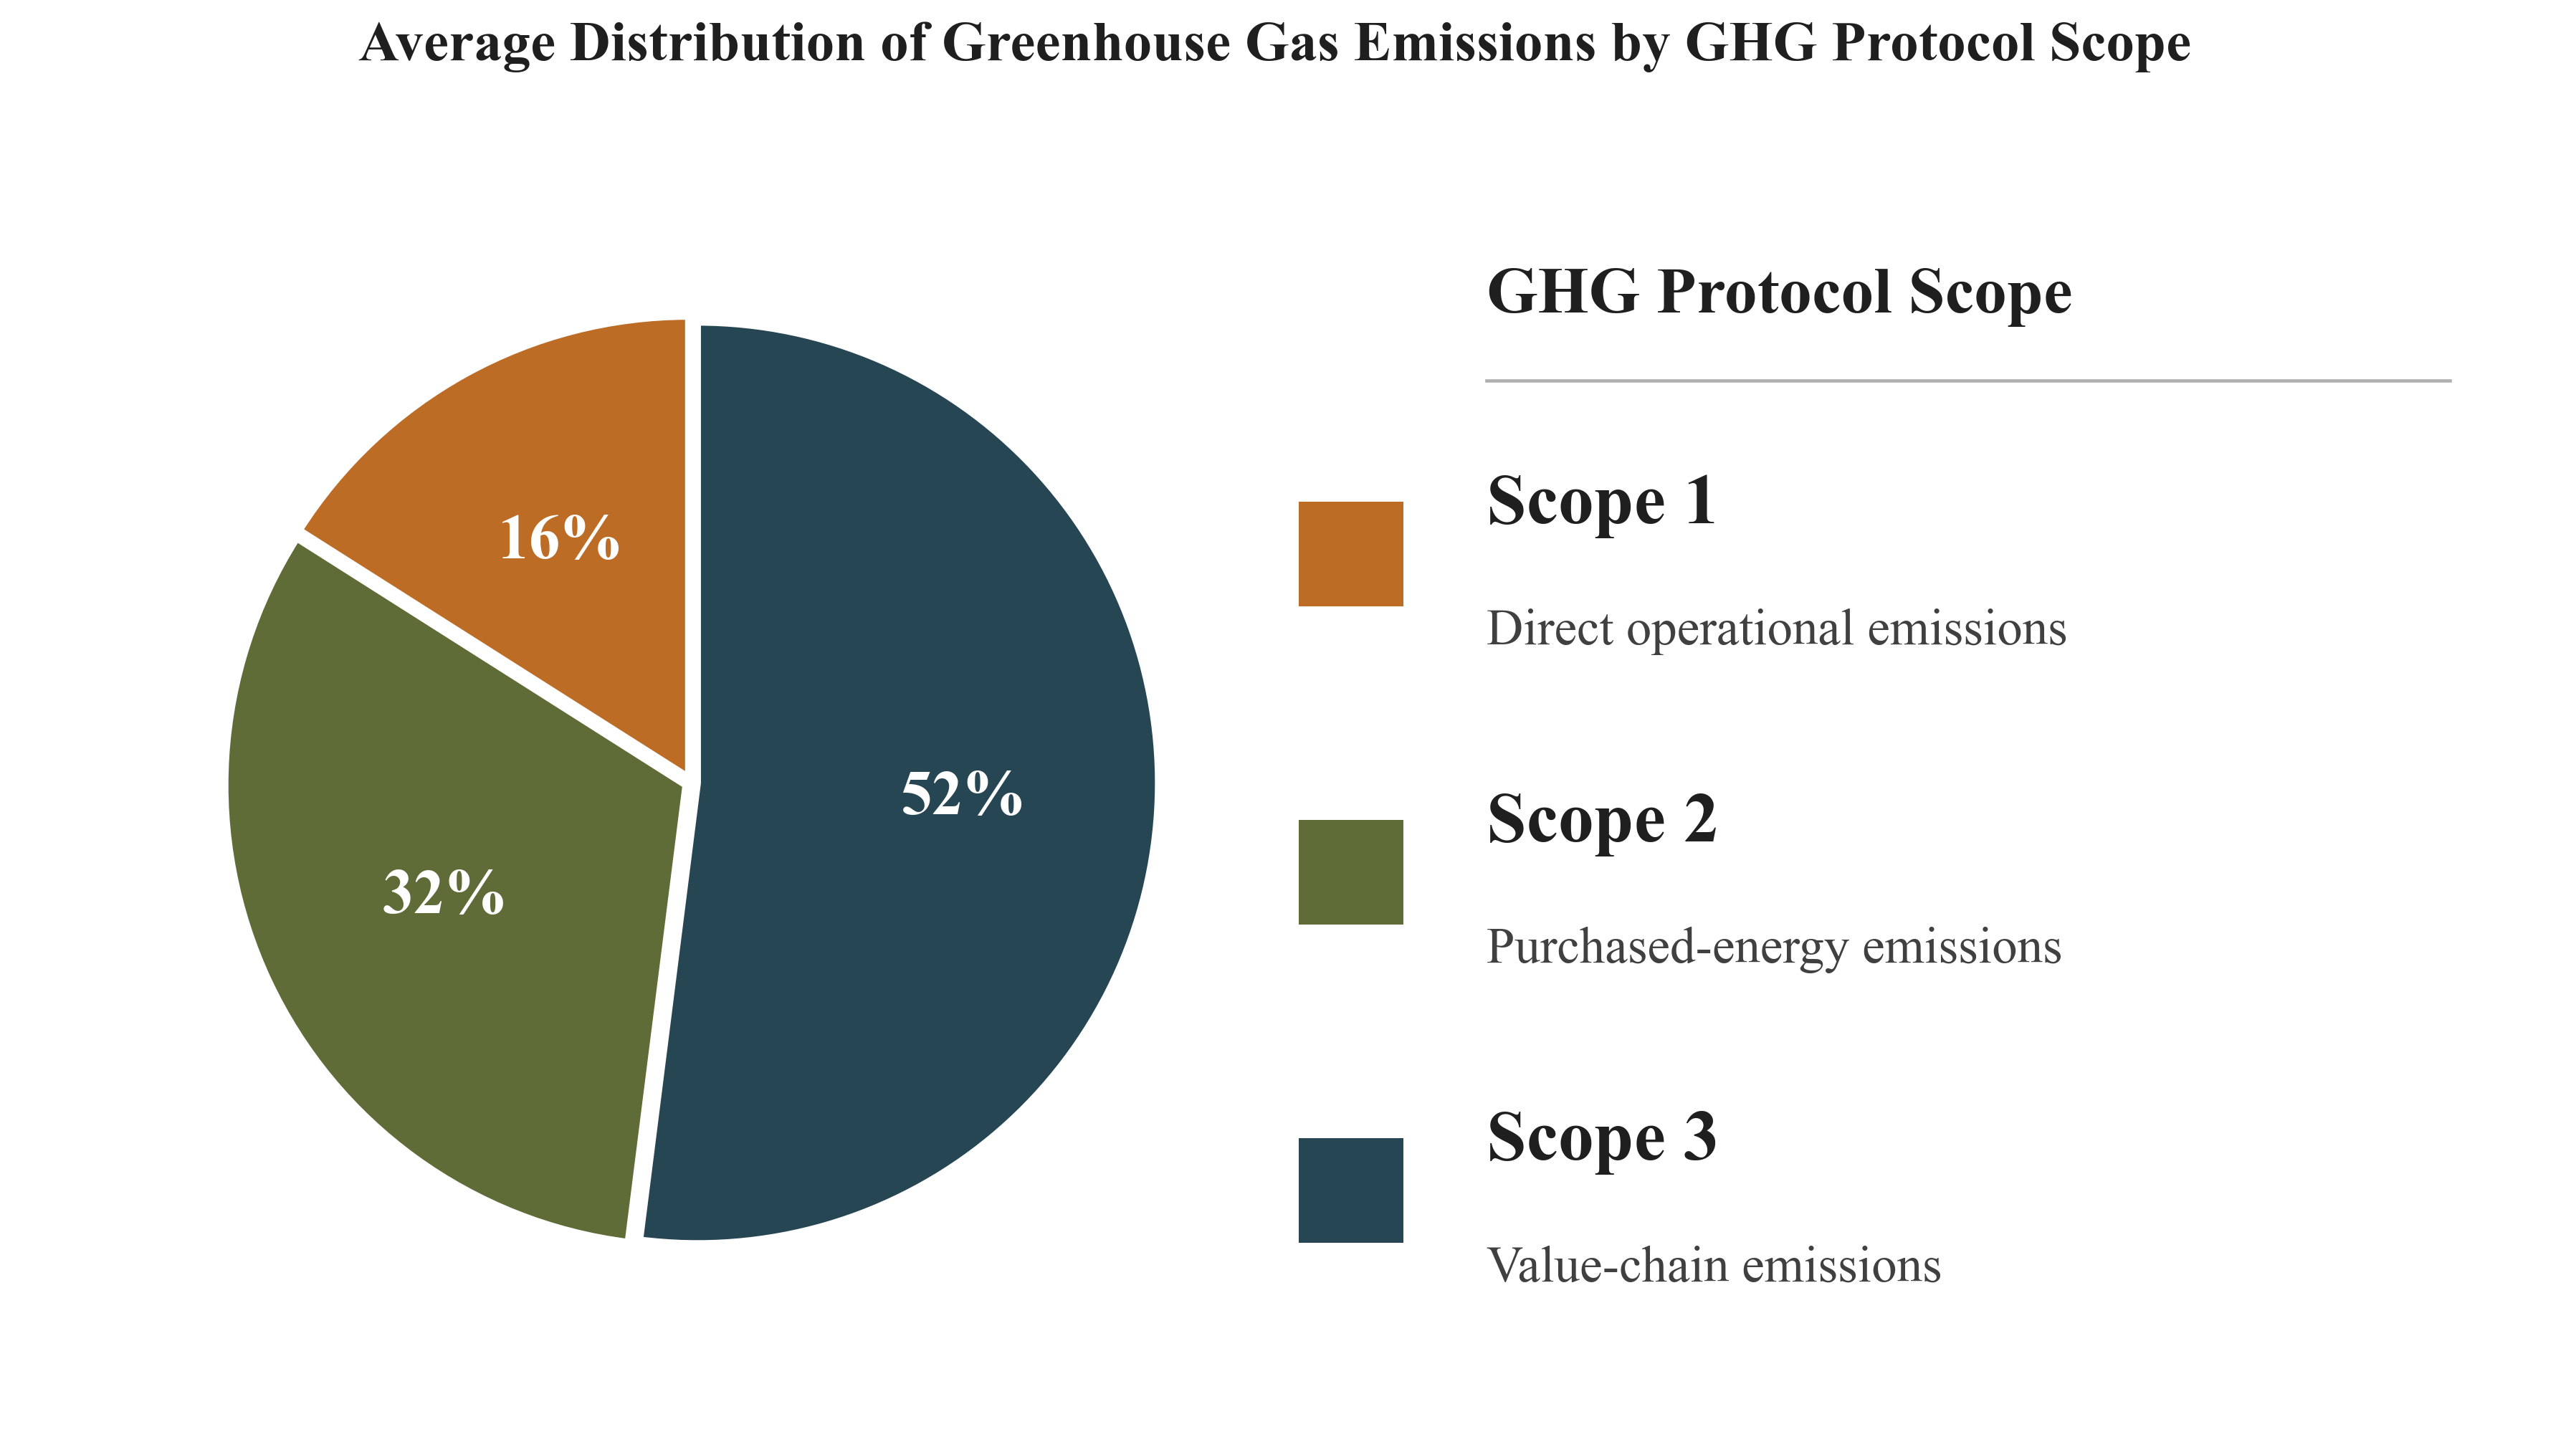

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# ---------------------------------------------------------
# Global font settings: Times New Roman
# ---------------------------------------------------------
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.serif": ["Times New Roman"],
    "font.size": 12
})

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
values = np.array([52, 32, 16])

# Pie order: Scope 3, Scope 2, Scope 1
colors = [
    "#264653",  # Scope 3
    "#606C38",  # Scope 2
    "#BC6C25"   # Scope 1
]

explode = [0.015, 0.015, 0.015]

# ---------------------------------------------------------
# Figure setup
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12.4, 7.3), dpi=300)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ---------------------------------------------------------
# Pie chart
# ---------------------------------------------------------
wedges, _ = ax.pie(
    values,
    startangle=90,
    counterclock=False,
    colors=colors,
    radius=1.10,
    explode=explode,
    wedgeprops=dict(
        edgecolor="white",
        linewidth=2.2
    )
)

# ---------------------------------------------------------
# Percentage labels inside pie slices
# ---------------------------------------------------------
for i, wedge in enumerate(wedges):
    angle = (wedge.theta1 + wedge.theta2) / 2

    x = 0.65 * np.cos(np.deg2rad(angle))
    y = 0.65 * np.sin(np.deg2rad(angle))

    ax.text(
        x,
        y,
        f"{values[i]}%",
        ha="center",
        va="center",
        fontsize=21,
        fontweight="bold",
        fontname="Times New Roman",
        color="white",
        zorder=5
    )

# ---------------------------------------------------------
# Structured right-side GHG Protocol Scope panel
# ---------------------------------------------------------
square_x = 1.45
text_x = 1.90

# Panel heading
ax.text(
    text_x,
    1.16,
    "GHG Protocol Scope",
    ha="left",
    va="center",
    fontsize=22,
    fontweight="bold",
    fontname="Times New Roman",
    color="#1F1F1F"
)

# Divider line
ax.plot(
    [text_x, 4.20],
    [0.96, 0.96],
    color="#AFAFAF",
    lw=1.1
)

# Panel contents: Scope 1 → Scope 2 → Scope 3
panel_items = [
    {
        "scope": "Scope 1",
        "description": "Direct operational emissions",
        "color": "#BC6C25",
        "y": 0.56
    },
    {
        "scope": "Scope 2",
        "description": "Purchased-energy emissions",
        "color": "#606C38",
        "y": -0.20
    },
    {
        "scope": "Scope 3",
        "description": "Value-chain emissions",
        "color": "#264653",
        "y": -0.96
    }
]

for item in panel_items:

    # Larger coloured square
    marker = Rectangle(
        (square_x, item["y"] - 0.14),
        0.25,
        0.25,
        facecolor=item["color"],
        edgecolor="none",
        zorder=4
    )
    ax.add_patch(marker)

    # Scope name
    ax.text(
        text_x,
        item["y"] + 0.10,
        item["scope"],
        ha="left",
        va="center",
        fontsize=24,
        fontweight="bold",
        fontname="Times New Roman",
        color="#1F1F1F",
        zorder=4
    )

    # Scope definition
    ax.text(
        text_x,
        item["y"] - 0.20,
        item["description"],
        ha="left",
        va="center",
        fontsize=17,
        fontname="Times New Roman",
        color="#404040",
        zorder=4
    )

# ---------------------------------------------------------
# Figure title
# ---------------------------------------------------------
fig.suptitle(
    "Average Distribution of Greenhouse Gas Emissions by GHG Protocol Scope",
    fontsize=19,
    fontweight="bold",
    fontname="Times New Roman",
    color="#1F1F1F",
    y=0.96
)

# ---------------------------------------------------------
# Final layout
# ---------------------------------------------------------
ax.set_aspect("equal")
ax.set_xlim(-1.60, 4.45)
ax.set_ylim(-1.50, 1.50)
ax.axis("off")

fig.subplots_adjust(
    left=0.03,
    right=0.98,
    top=0.88,
    bottom=0.07
)

# ---------------------------------------------------------
# Save high-resolution figure
# ---------------------------------------------------------
fig.savefig(
    "ghg_emissions_scope_share_2020.png",
    dpi=300,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.15
)

plt.show()

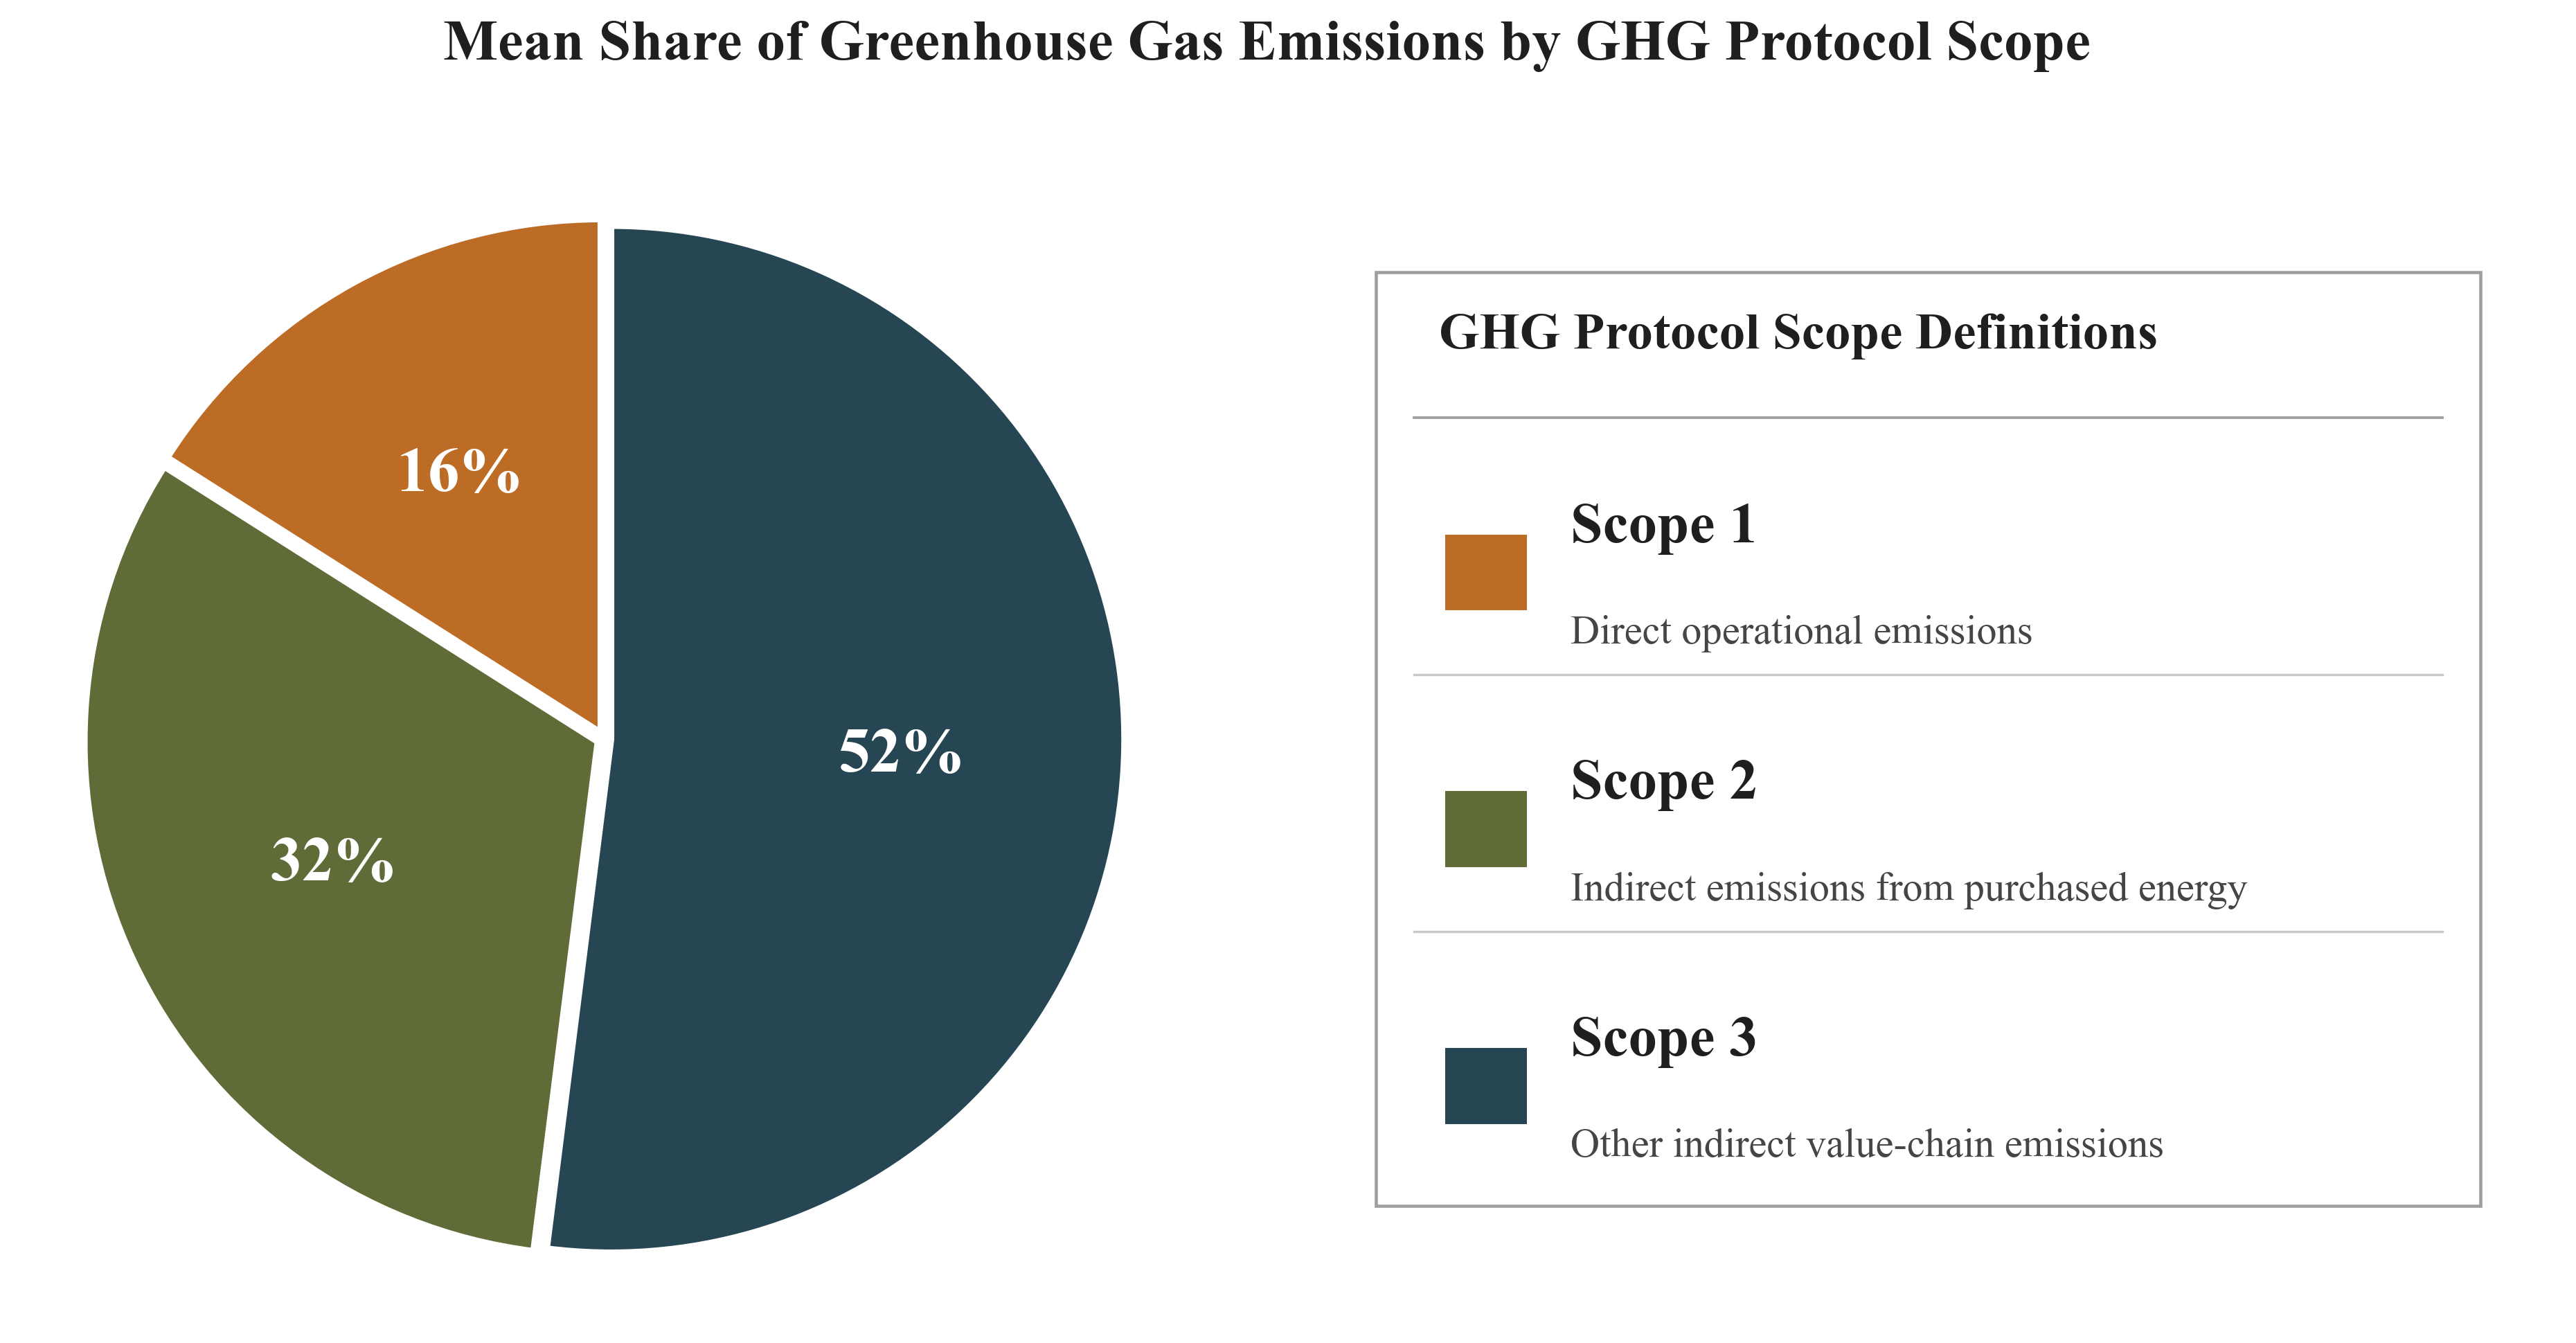

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# ---------------------------------------------------------
# Global typography: Times New Roman
# ---------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12
})

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
values = np.array([52, 32, 16])

# Pie order: Scope 3, Scope 2, Scope 1
colors = [
    "#264653",  # Scope 3
    "#606C38",  # Scope 2
    "#BC6C25"   # Scope 1
]

explode = [0.015, 0.015, 0.015]

# ---------------------------------------------------------
# Figure and layout
# ---------------------------------------------------------
fig = plt.figure(figsize=(13.2, 7.2), dpi=300)
fig.patch.set_facecolor("white")

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[1.05, 1.10],
    wspace=0.08
)

ax_pie = fig.add_subplot(gs[0, 0])
ax_panel = fig.add_subplot(gs[0, 1])

ax_pie.set_facecolor("white")
ax_panel.set_facecolor("white")

# ---------------------------------------------------------
# Pie chart
# ---------------------------------------------------------
wedges, _ = ax_pie.pie(
    values,
    startangle=90,
    counterclock=False,
    colors=colors,
    radius=1.10,
    explode=explode,
    wedgeprops=dict(
        edgecolor="white",
        linewidth=2.2
    )
)

# Percentages inside pie slices
for i, wedge in enumerate(wedges):
    angle = (wedge.theta1 + wedge.theta2) / 2

    x = 0.64 * np.cos(np.deg2rad(angle))
    y = 0.64 * np.sin(np.deg2rad(angle))

    ax_pie.text(
        x,
        y,
        f"{values[i]}%",
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold",
        fontname="Times New Roman",
        color="white",
        zorder=5
    )

ax_pie.set_aspect("equal")
ax_pie.axis("off")

# ---------------------------------------------------------
# Structured right-side panel
# ---------------------------------------------------------
ax_panel.axis("off")

# Main outer box
panel_box = Rectangle(
    (0.06, 0.10),
    0.88,
    0.80,
    transform=ax_panel.transAxes,
    facecolor="white",
    edgecolor="#9E9E9E",
    linewidth=1.1,
    zorder=1
)

ax_panel.add_patch(panel_box)

# Panel heading
ax_panel.text(
    0.11,
    0.845,
    "GHG Protocol Scope Definitions",
    transform=ax_panel.transAxes,
    ha="left",
    va="center",
    fontsize=18,
    fontweight="bold",
    fontname="Times New Roman",
    color="#1F1F1F",
    zorder=3
)

# Header divider
ax_panel.plot(
    [0.09, 0.91],
    [0.775, 0.775],
    transform=ax_panel.transAxes,
    color="#9E9E9E",
    lw=0.9,
    zorder=2
)

# Horizontal row dividers
for y_line in [0.555, 0.335]:
    ax_panel.plot(
        [0.09, 0.91],
        [y_line, y_line],
        transform=ax_panel.transAxes,
        color="#C8C8C8",
        lw=0.8,
        zorder=2
    )

# Scope definitions, in standard Scope 1 -> Scope 3 order
panel_items = [
    {
        "scope": "Scope 1",
        "description": "Direct operational emissions",
        "color": "#BC6C25",
        "y": 0.655
    },
    {
        "scope": "Scope 2",
        "description": "Indirect emissions from purchased energy",
        "color": "#606C38",
        "y": 0.435
    },
    {
        "scope": "Scope 3",
        "description": "Other indirect value-chain emissions",
        "color": "#264653",
        "y": 0.215
    }
]

for item in panel_items:

    # Colored square marker
    marker = Rectangle(
        (0.115, item["y"] - 0.045),
        0.065,
        0.065,
        transform=ax_panel.transAxes,
        facecolor=item["color"],
        edgecolor="none",
        zorder=3
    )

    ax_panel.add_patch(marker)

    # Scope label
    ax_panel.text(
        0.215,
        item["y"] + 0.025,
        item["scope"],
        transform=ax_panel.transAxes,
        ha="left",
        va="center",
        fontsize=20,
        fontweight="bold",
        fontname="Times New Roman",
        color="#1F1F1F",
        zorder=3
    )

    # Scope definition
    ax_panel.text(
        0.215,
        item["y"] - 0.065,
        item["description"],
        transform=ax_panel.transAxes,
        ha="left",
        va="center",
        fontsize=14,
        fontname="Times New Roman",
        color="#454545",
        zorder=3
    )

# ---------------------------------------------------------
# Figure title
# ---------------------------------------------------------
fig.suptitle(
    "Mean Share of Greenhouse Gas Emissions by GHG Protocol Scope",
    fontsize=20,
    fontweight="bold",
    fontname="Times New Roman",
    color="#1F1F1F",
    y=0.95
)

# ---------------------------------------------------------
# Layout and export
# ---------------------------------------------------------
fig.subplots_adjust(
    left=0.04,
    right=0.97,
    top=0.86,
    bottom=0.08
)

fig.savefig(
    "ghg_emissions_scope_partitioned_panel.png",
    dpi=300,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.15
)

plt.show()

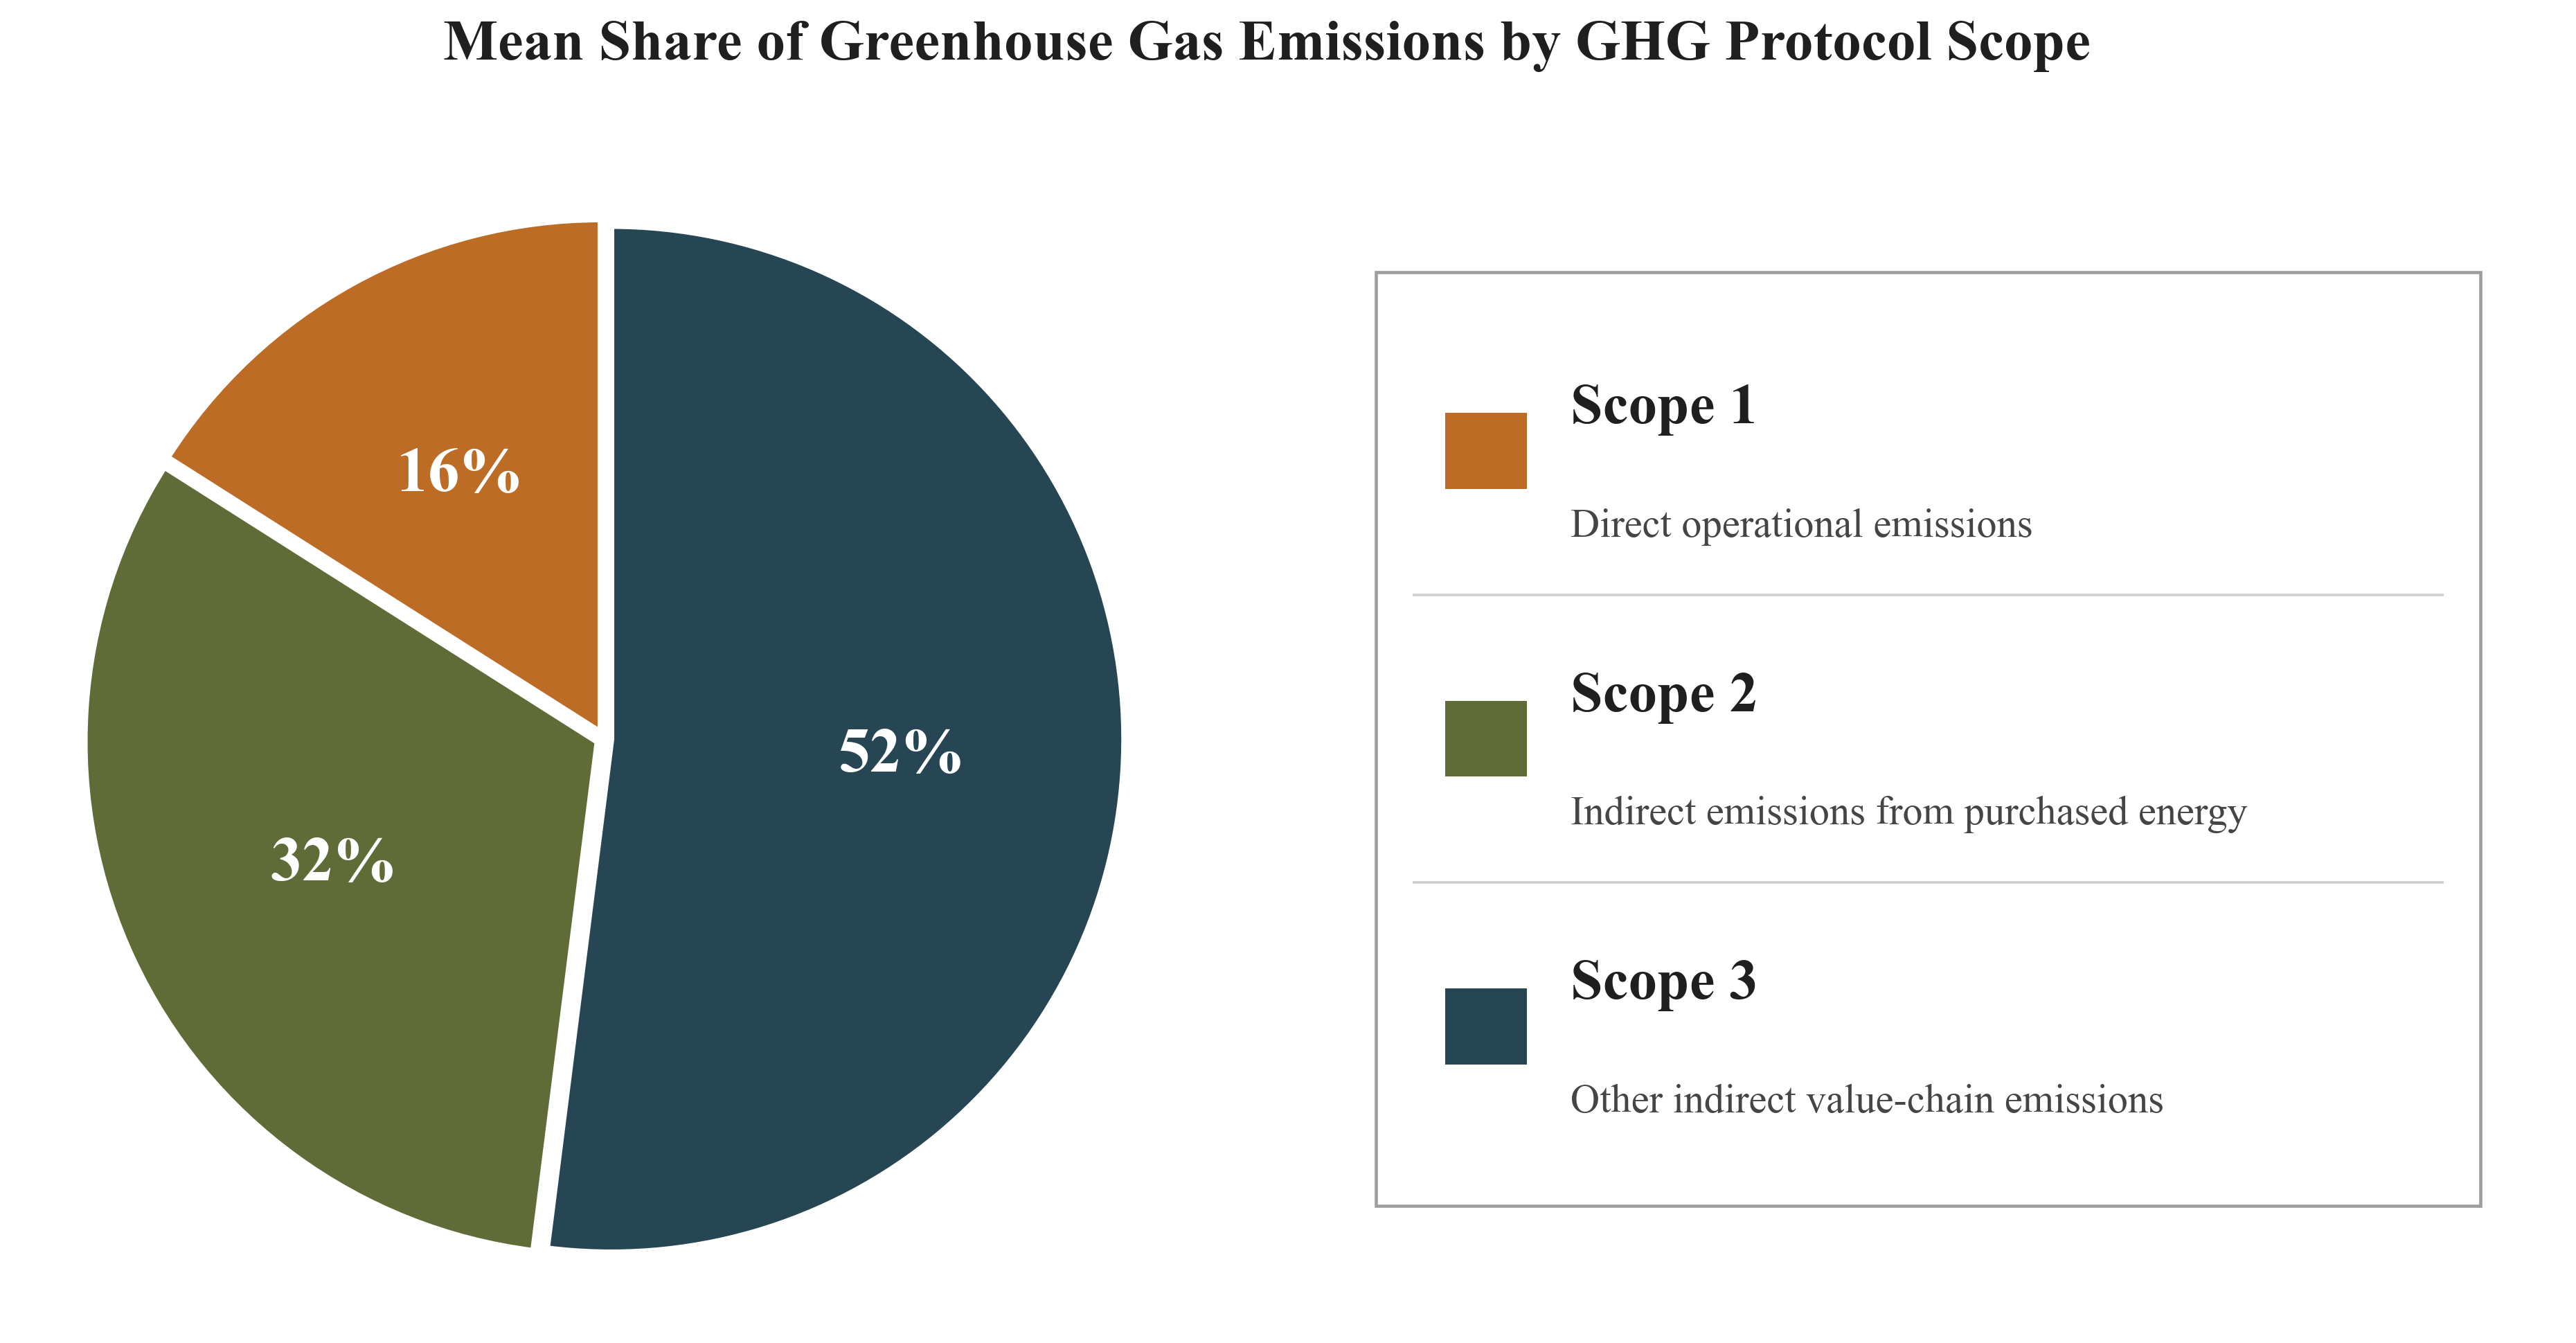

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# ---------------------------------------------------------
# Global Typography
# ---------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12
})

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
values = np.array([52, 32, 16])

# Pie chart order: Scope 3, Scope 2, Scope 1
colors = [
    "#264653",  # Scope 3
    "#606C38",  # Scope 2
    "#BC6C25"   # Scope 1
]

explode = [0.015, 0.015, 0.015]

# ---------------------------------------------------------
# Figure Layout
# ---------------------------------------------------------
fig = plt.figure(figsize=(13.2, 7.2), dpi=300)
fig.patch.set_facecolor("white")

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[1.05, 1.10],
    wspace=0.08
)

ax_pie = fig.add_subplot(gs[0, 0])
ax_panel = fig.add_subplot(gs[0, 1])

ax_pie.set_facecolor("white")
ax_panel.set_facecolor("white")

# ---------------------------------------------------------
# Pie Chart
# ---------------------------------------------------------
wedges, _ = ax_pie.pie(
    values,
    startangle=90,
    counterclock=False,
    colors=colors,
    radius=1.10,
    explode=explode,
    wedgeprops=dict(
        edgecolor="white",
        linewidth=2.2
    )
)

# Percentage labels inside pie chart
for i, wedge in enumerate(wedges):
    angle = (wedge.theta1 + wedge.theta2) / 2

    x = 0.64 * np.cos(np.deg2rad(angle))
    y = 0.64 * np.sin(np.deg2rad(angle))

    ax_pie.text(
        x,
        y,
        f"{values[i]}%",
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold",
        color="white",
        zorder=5
    )

ax_pie.set_aspect("equal")
ax_pie.axis("off")

# ---------------------------------------------------------
# Right Scope Definition Panel
# ---------------------------------------------------------
ax_panel.axis("off")

# Outer panel box
panel_left = 0.06
panel_bottom = 0.10
panel_width = 0.88
panel_height = 0.80

panel_right = panel_left + panel_width
panel_top = panel_bottom + panel_height

panel_box = Rectangle(
    (panel_left, panel_bottom),
    panel_width,
    panel_height,
    transform=ax_panel.transAxes,
    facecolor="white",
    edgecolor="#9E9E9E",
    linewidth=1.1,
    zorder=1
)

ax_panel.add_patch(panel_box)

# Equal spacing from panel top and bottom
inner_padding = 0.03

content_top = panel_top - inner_padding
content_bottom = panel_bottom + inner_padding
content_height = content_top - content_bottom

# Three perfectly equal rows
row_height = content_height / 3

# Divider lines
divider_left = panel_left + 0.03
divider_right = panel_right - 0.03

for i in range(1, 3):
    divider_y = content_top - (row_height * i)

    ax_panel.plot(
        [divider_left, divider_right],
        [divider_y, divider_y],
        transform=ax_panel.transAxes,
        color="#D0D0D0",
        linewidth=0.9,
        zorder=2
    )

# Scope information
panel_items = [
    {
        "scope": "Scope 1",
        "description": "Direct operational emissions",
        "color": "#BC6C25"
    },
    {
        "scope": "Scope 2",
        "description": "Indirect emissions from purchased energy",
        "color": "#606C38"
    },
    {
        "scope": "Scope 3",
        "description": "Other indirect value-chain emissions",
        "color": "#264653"
    }
]

# Horizontal alignment settings
marker_x = panel_left + 0.055
marker_size = 0.065

# Text begins neatly to the right of colored square
text_x = marker_x + marker_size + 0.035

for i, item in enumerate(panel_items):

    # Find center of each equal row
    row_center_y = content_top - (row_height * (i + 0.5))

    # Colored square
    marker = Rectangle(
        (
            marker_x,
            row_center_y - (marker_size / 2)
        ),
        marker_size,
        marker_size,
        transform=ax_panel.transAxes,
        facecolor=item["color"],
        edgecolor="none",
        zorder=3
    )

    ax_panel.add_patch(marker)

    # Scope label
    ax_panel.text(
        text_x,
        row_center_y + 0.035,
        item["scope"],
        transform=ax_panel.transAxes,
        ha="left",
        va="center",
        fontsize=20,
        fontweight="bold",
        color="#1F1F1F",
        zorder=3
    )

    # Scope description
    ax_panel.text(
        text_x,
        row_center_y - 0.065,
        item["description"],
        transform=ax_panel.transAxes,
        ha="left",
        va="center",
        fontsize=14,
        color="#454545",
        zorder=3
    )

# ---------------------------------------------------------
# Main Figure Title
# ---------------------------------------------------------
fig.suptitle(
    "Mean Share of Greenhouse Gas Emissions by GHG Protocol Scope",
    fontsize=20,
    fontweight="bold",
    color="#1F1F1F",
    y=0.95
)

# ---------------------------------------------------------
# Final Layout
# ---------------------------------------------------------
fig.subplots_adjust(
    left=0.04,
    right=0.97,
    top=0.86,
    bottom=0.08
)

# ---------------------------------------------------------
# Save Image
# ---------------------------------------------------------
fig.savefig(
    "ghg_emissions_scope_partitioned_panel.png",
    dpi=300,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.15
)

plt.show()

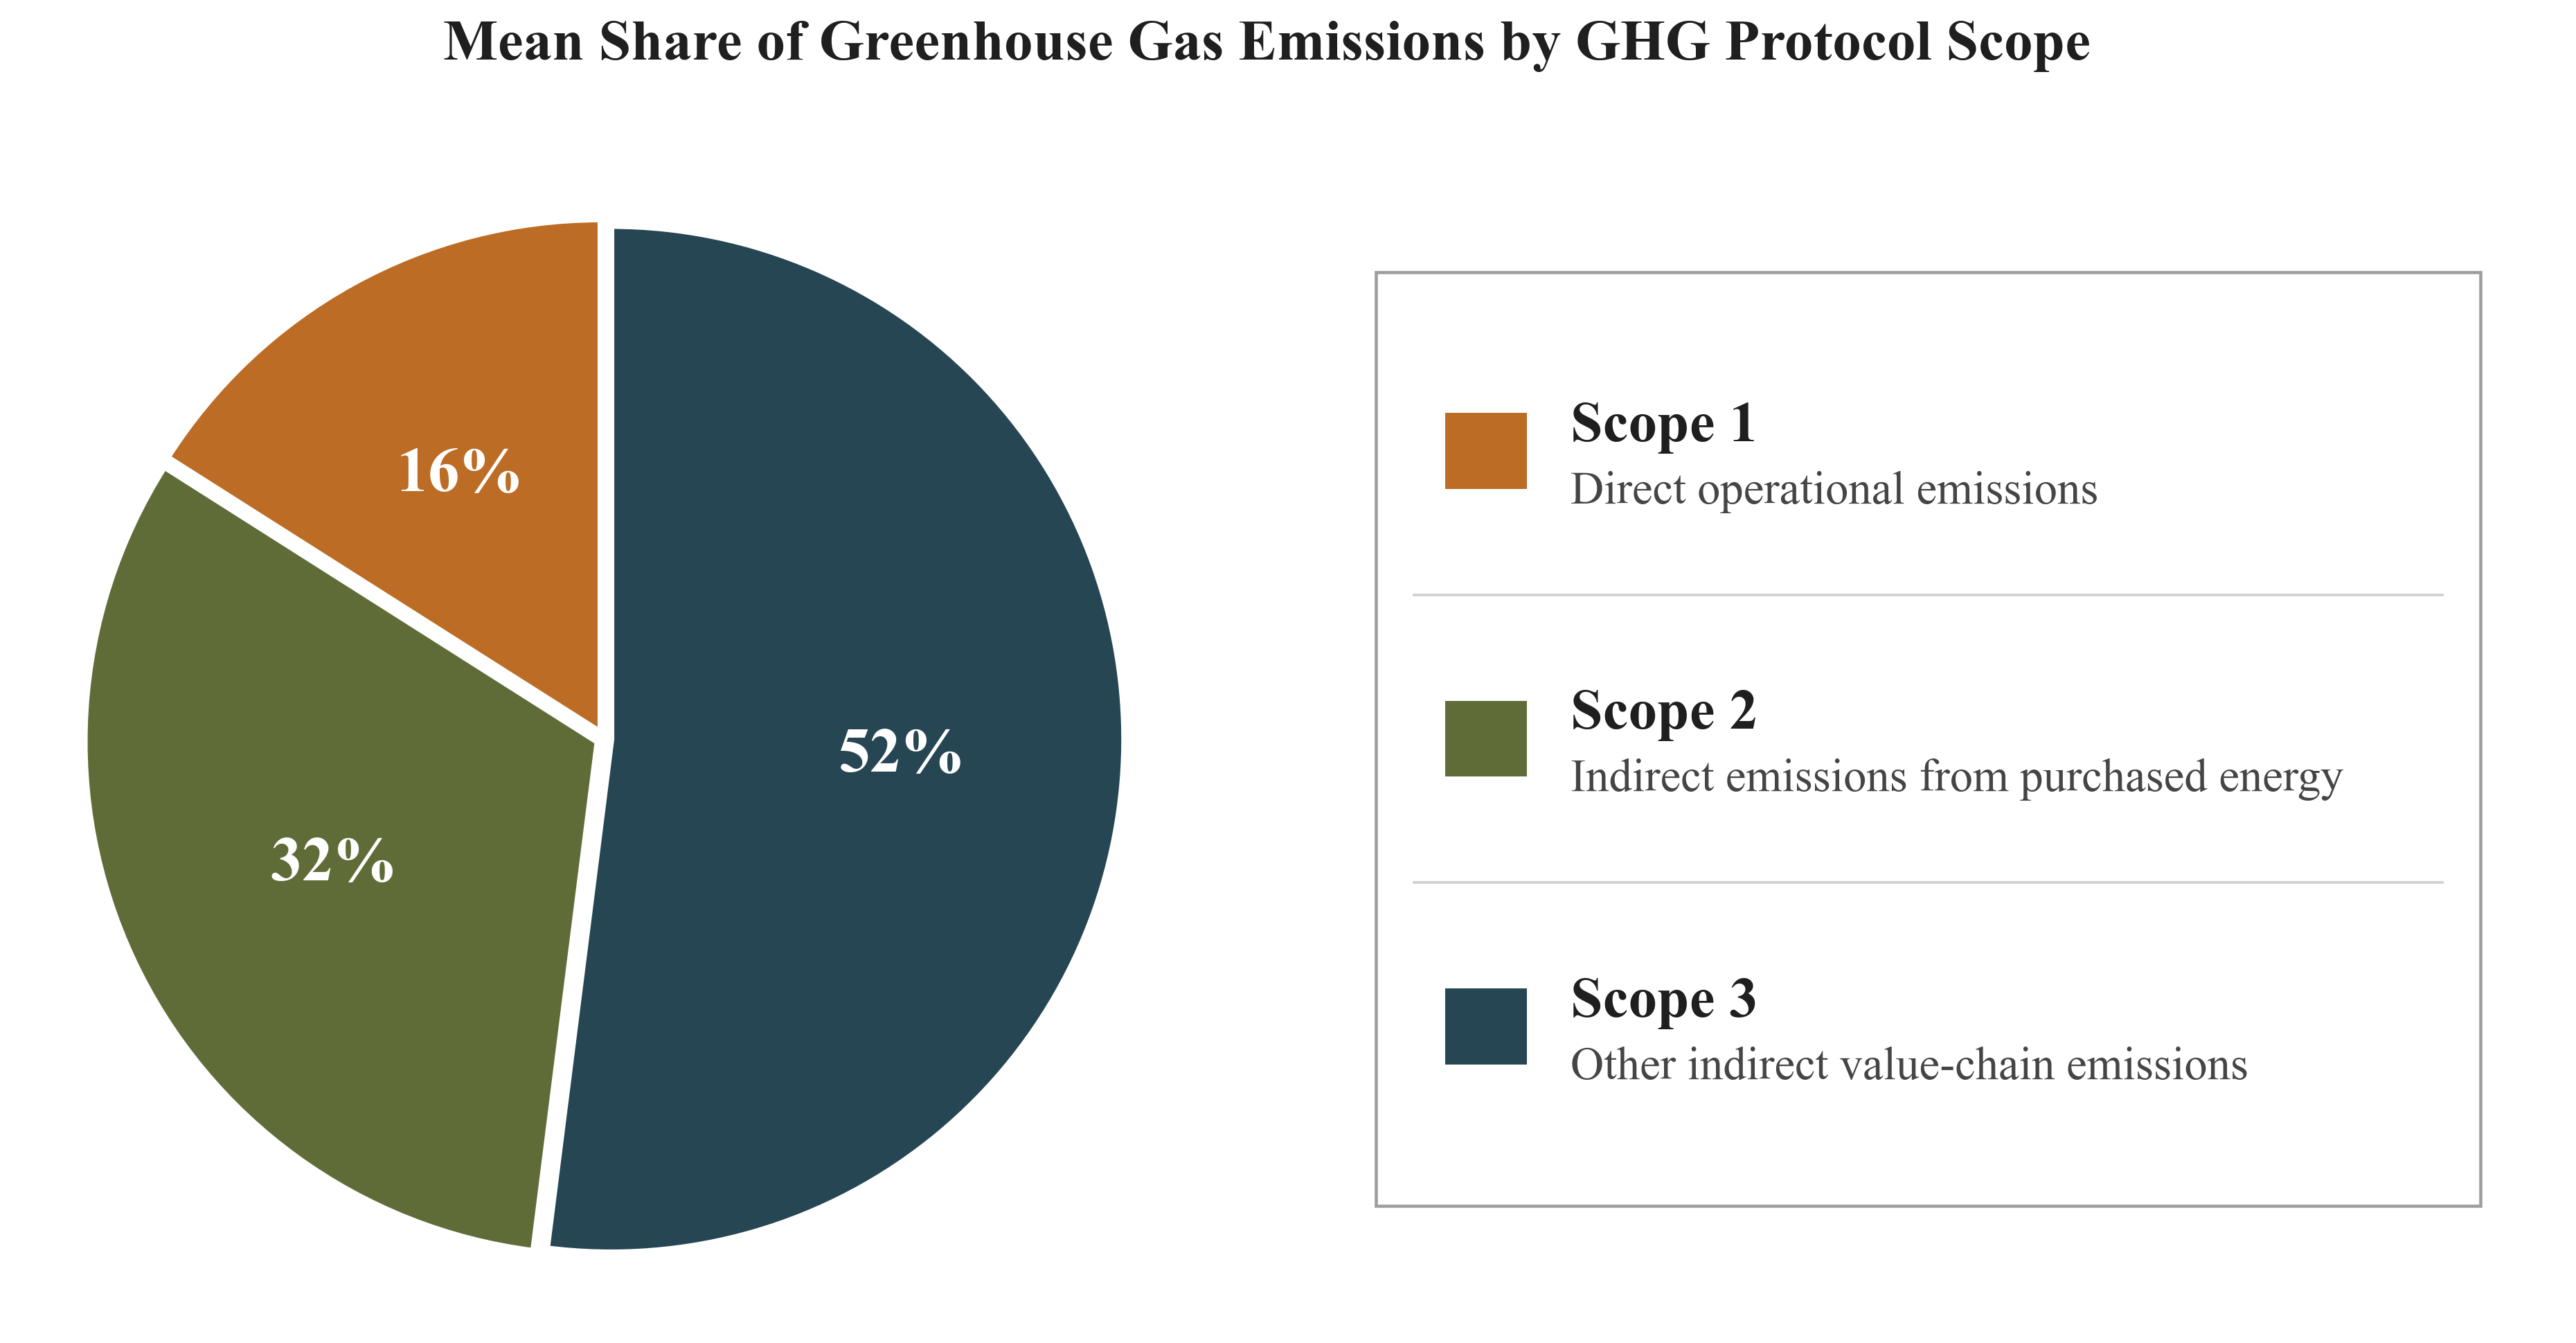

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# ---------------------------------------------------------
# Global Typography: Times New Roman
# ---------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12
})

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
values = np.array([52, 32, 16])

# Pie chart order: Scope 3, Scope 2, Scope 1
colors = [
    "#264653",  # Scope 3
    "#606C38",  # Scope 2
    "#BC6C25"   # Scope 1
]

explode = [0.015, 0.015, 0.015]

# ---------------------------------------------------------
# Figure Layout
# ---------------------------------------------------------
fig = plt.figure(figsize=(13.2, 7.2), dpi=300)
fig.patch.set_facecolor("white")

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[1.05, 1.10],
    wspace=0.08
)

ax_pie = fig.add_subplot(gs[0, 0])
ax_panel = fig.add_subplot(gs[0, 1])

ax_pie.set_facecolor("white")
ax_panel.set_facecolor("white")

# ---------------------------------------------------------
# Pie Chart
# ---------------------------------------------------------
wedges, _ = ax_pie.pie(
    values,
    startangle=90,
    counterclock=False,
    colors=colors,
    radius=1.10,
    explode=explode,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2.2
    }
)

# Percentage labels
for i, wedge in enumerate(wedges):
    angle = (wedge.theta1 + wedge.theta2) / 2

    x = 0.64 * np.cos(np.deg2rad(angle))
    y = 0.64 * np.sin(np.deg2rad(angle))

    ax_pie.text(
        x,
        y,
        f"{values[i]}%",
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold",
        fontname="Times New Roman",
        color="white",
        zorder=5
    )

ax_pie.set_aspect("equal")
ax_pie.axis("off")

# ---------------------------------------------------------
# Right Scope Definition Panel
# ---------------------------------------------------------
ax_panel.axis("off")

# Outer panel dimensions
panel_left = 0.06
panel_bottom = 0.10
panel_width = 0.88
panel_height = 0.80

panel_right = panel_left + panel_width
panel_top = panel_bottom + panel_height

# Outer box
panel_box = Rectangle(
    (panel_left, panel_bottom),
    panel_width,
    panel_height,
    transform=ax_panel.transAxes,
    facecolor="white",
    edgecolor="#9E9E9E",
    linewidth=1.1,
    zorder=1
)

ax_panel.add_patch(panel_box)

# Equal upper and lower inner spacing
inner_padding = 0.03

content_top = panel_top - inner_padding
content_bottom = panel_bottom + inner_padding
content_height = content_top - content_bottom

# Three equal rows
row_height = content_height / 3

# Row divider lines
divider_left = panel_left + 0.03
divider_right = panel_right - 0.03

for i in range(1, 3):
    divider_y = content_top - (row_height * i)

    ax_panel.plot(
        [divider_left, divider_right],
        [divider_y, divider_y],
        transform=ax_panel.transAxes,
        color="#D0D0D0",
        linewidth=0.9,
        zorder=2
    )

# Scope information
panel_items = [
    {
        "scope": "Scope 1",
        "description": "Direct operational emissions",
        "color": "#BC6C25"
    },
    {
        "scope": "Scope 2",
        "description": "Indirect emissions from purchased energy",
        "color": "#606C38"
    },
    {
        "scope": "Scope 3",
        "description": "Other indirect value-chain emissions",
        "color": "#264653"
    }
]

# Marker and text positions
marker_x = panel_left + 0.055
marker_size = 0.065
text_x = marker_x + marker_size + 0.035

for i, item in enumerate(panel_items):

    # Centre of each row
    row_center_y = content_top - (row_height * (i + 0.5))

    # Colour square
    marker = Rectangle(
        (
            marker_x,
            row_center_y - (marker_size / 2)
        ),
        marker_size,
        marker_size,
        transform=ax_panel.transAxes,
        facecolor=item["color"],
        edgecolor="none",
        zorder=3
    )

    ax_panel.add_patch(marker)

    # Scope heading
    ax_panel.text(
        text_x,
        row_center_y + 0.020,
        item["scope"],
        transform=ax_panel.transAxes,
        ha="left",
        va="center",
        fontsize=20,
        fontweight="bold",
        fontname="Times New Roman",
        color="#1F1F1F",
        zorder=3
    )

    # Scope description: larger and closer to title
    ax_panel.text(
        text_x,
        row_center_y - 0.035,
        item["description"],
        transform=ax_panel.transAxes,
        ha="left",
        va="center",
        fontsize=16,
        fontname="Times New Roman",
        color="#454545",
        zorder=3
    )

# ---------------------------------------------------------
# Main Figure Title
# ---------------------------------------------------------
fig.suptitle(
    "Mean Share of Greenhouse Gas Emissions by GHG Protocol Scope",
    fontsize=20,
    fontweight="bold",
    fontname="Times New Roman",
    color="#1F1F1F",
    y=0.95
)

# ---------------------------------------------------------
# Final Layout
# ---------------------------------------------------------
fig.subplots_adjust(
    left=0.04,
    right=0.97,
    top=0.86,
    bottom=0.08
)

# ---------------------------------------------------------
# Save Figure
# ---------------------------------------------------------
fig.savefig(
    "ghg_emissions_scope_partitioned_panel.png",
    dpi=300,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.15
)

plt.show()

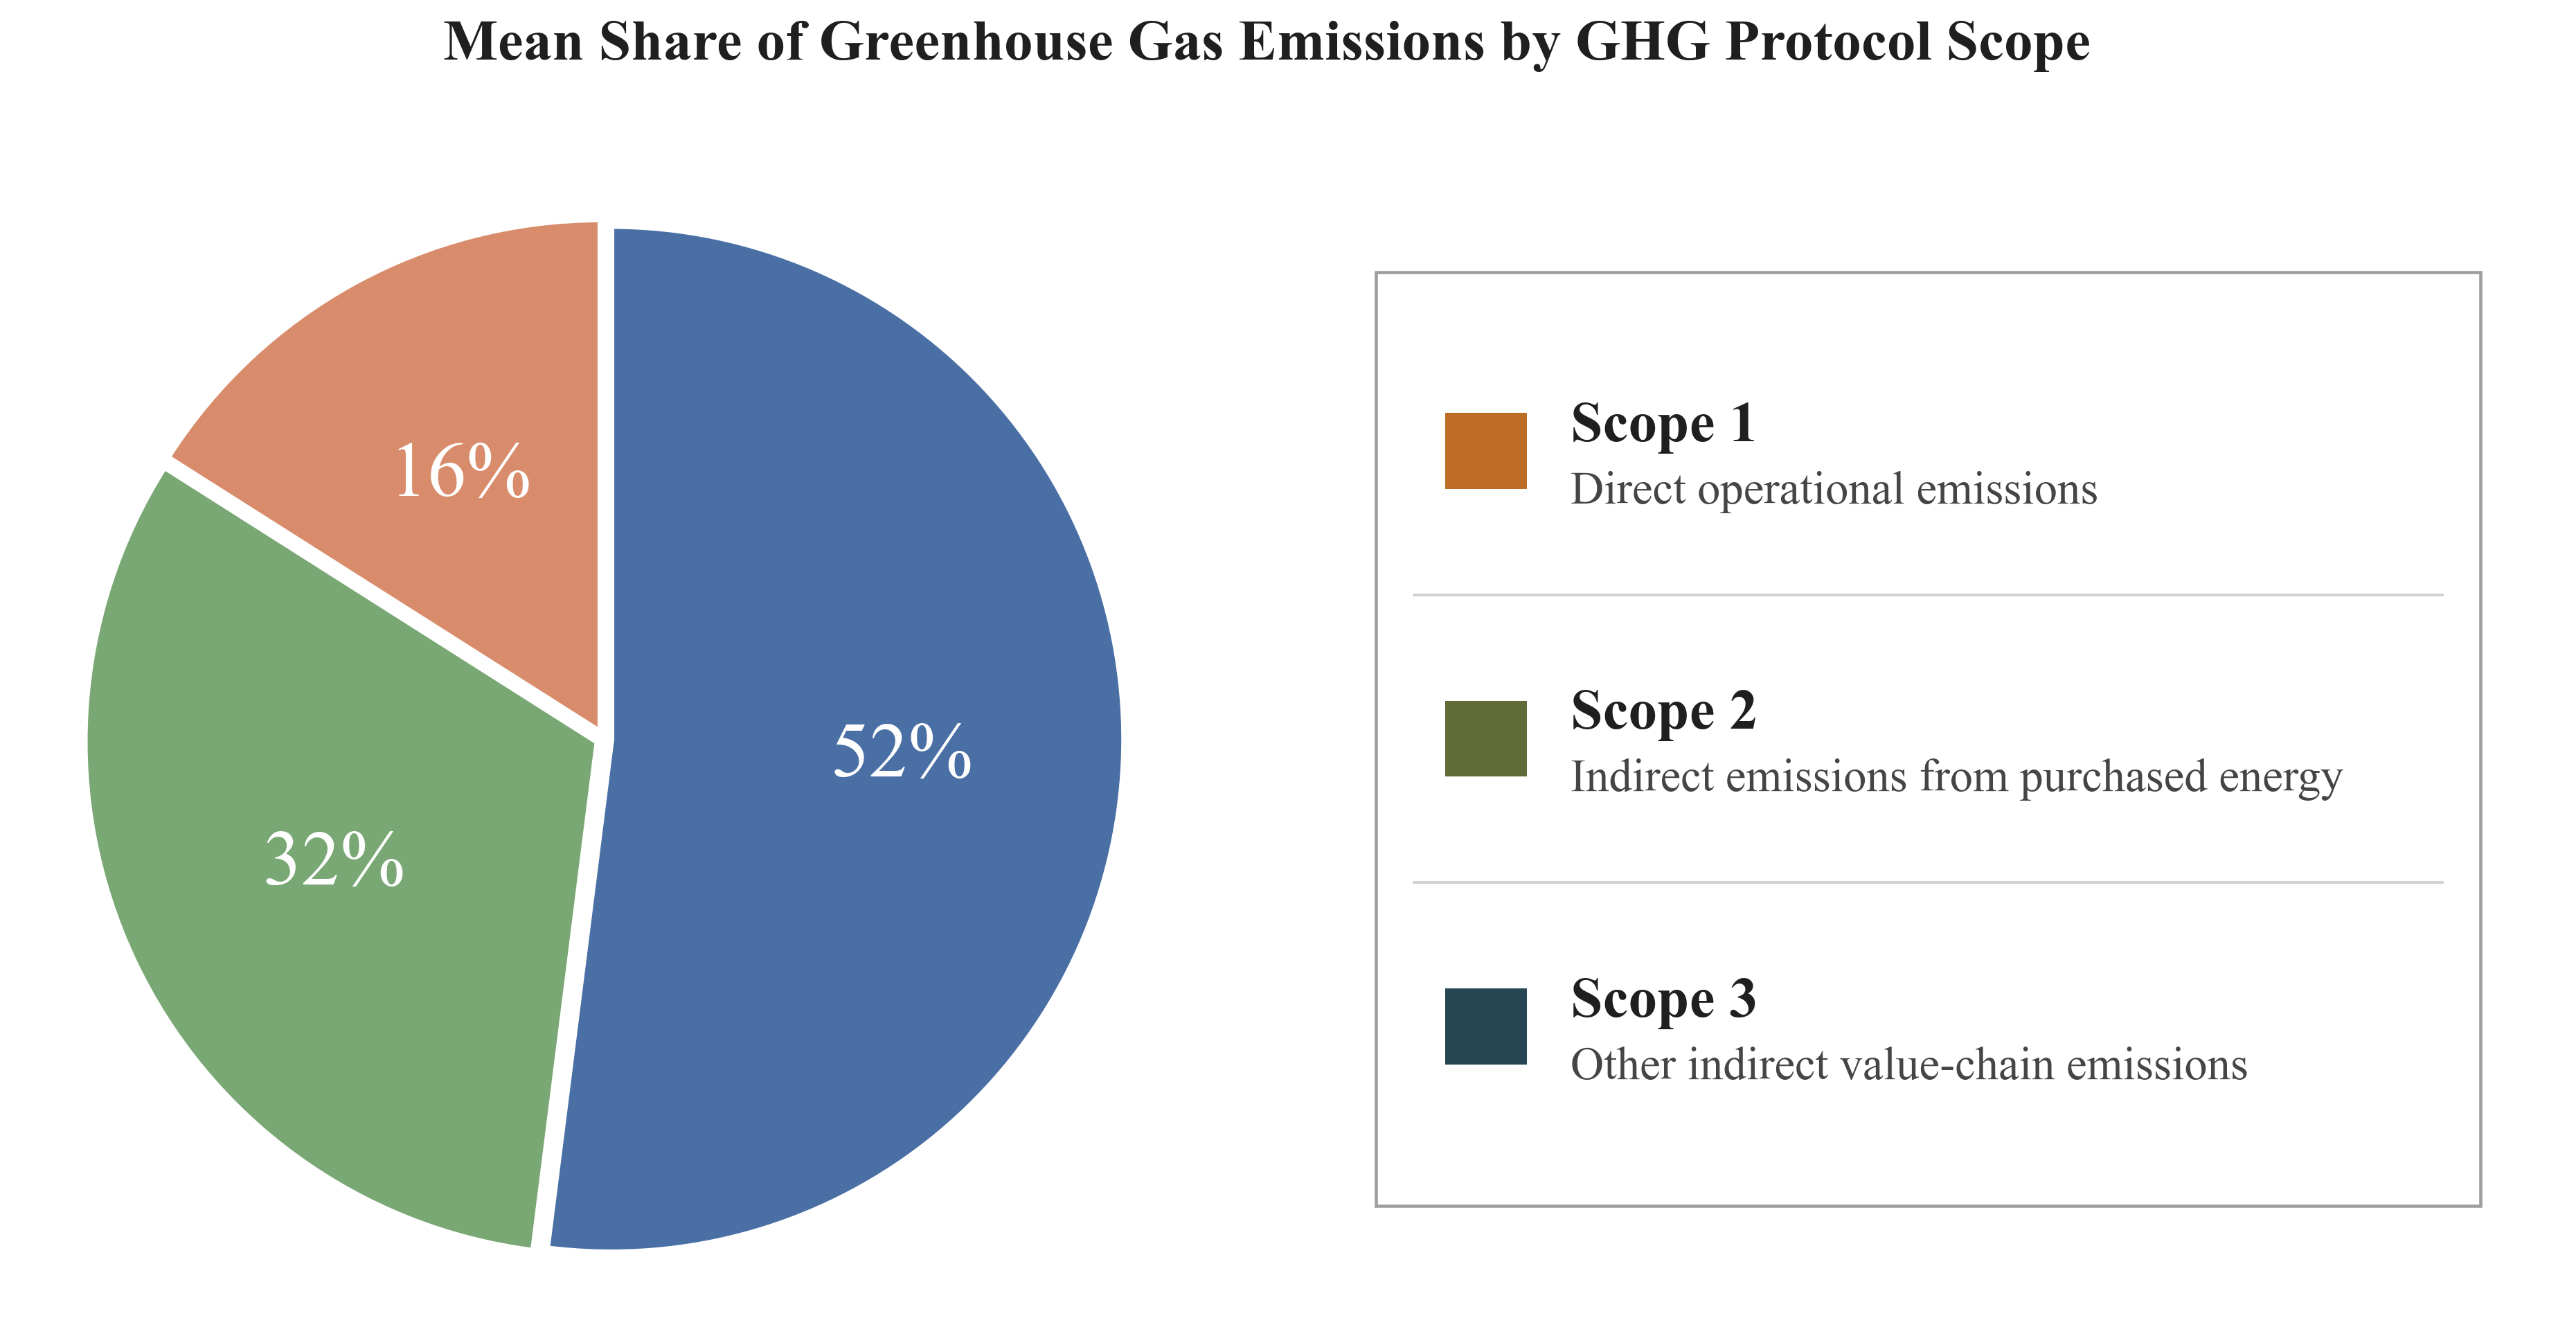

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# ---------------------------------------------------------
# Global Typography: Times New Roman
# ---------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 12
})

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
values = np.array([52, 32, 16])





colors = [
    "#4A6FA5",  # Scope 3 - Soft Blue
    "#7AA874",  # Scope 2 - Soft Green
    "#D98C6B"   # Scope 1 - Terracotta
]











explode = [0.015, 0.015, 0.015]

# ---------------------------------------------------------
# Figure Layout
# ---------------------------------------------------------
fig = plt.figure(figsize=(13.2, 7.2), dpi=300)
fig.patch.set_facecolor("white")

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[1.05, 1.10],
    wspace=0.08
)

ax_pie = fig.add_subplot(gs[0, 0])
ax_panel = fig.add_subplot(gs[0, 1])

ax_pie.set_facecolor("white")
ax_panel.set_facecolor("white")

# ---------------------------------------------------------
# Pie Chart
# ---------------------------------------------------------
wedges, _ = ax_pie.pie(
    values,
    startangle=90,
    counterclock=False,
    colors=colors,
    radius=1.10,
    explode=explode,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2.2
    }
)

# Percentage labels: bigger and regular weight
for i, wedge in enumerate(wedges):
    angle = (wedge.theta1 + wedge.theta2) / 2

    x = 0.64 * np.cos(np.deg2rad(angle))
    y = 0.64 * np.sin(np.deg2rad(angle))

    ax_pie.text(
        x,
        y,
        f"{values[i]}%",
        ha="center",
        va="center",
        fontsize=27,
        fontweight="normal",
        fontname="Times New Roman",
        color="white",
        zorder=5
    )

ax_pie.set_aspect("equal")
ax_pie.axis("off")

# ---------------------------------------------------------
# Right Scope Definition Panel
# ---------------------------------------------------------
ax_panel.axis("off")

# Outer panel dimensions
panel_left = 0.06
panel_bottom = 0.10
panel_width = 0.88
panel_height = 0.80

panel_right = panel_left + panel_width
panel_top = panel_bottom + panel_height

# Outer box
panel_box = Rectangle(
    (panel_left, panel_bottom),
    panel_width,
    panel_height,
    transform=ax_panel.transAxes,
    facecolor="white",
    edgecolor="#9E9E9E",
    linewidth=1.1,
    zorder=1
)

ax_panel.add_patch(panel_box)

# Equal upper and lower inner spacing
inner_padding = 0.03

content_top = panel_top - inner_padding
content_bottom = panel_bottom + inner_padding
content_height = content_top - content_bottom

# Three equal rows
row_height = content_height / 3

# Row divider lines
divider_left = panel_left + 0.03
divider_right = panel_right - 0.03

for i in range(1, 3):
    divider_y = content_top - (row_height * i)

    ax_panel.plot(
        [divider_left, divider_right],
        [divider_y, divider_y],
        transform=ax_panel.transAxes,
        color="#D0D0D0",
        linewidth=0.9,
        zorder=2
    )

# Scope information
panel_items = [
    {
        "scope": "Scope 1",
        "description": "Direct operational emissions",
        "color": "#BC6C25"
    },
    {
        "scope": "Scope 2",
        "description": "Indirect emissions from purchased energy",
        "color": "#606C38"
    },
    {
        "scope": "Scope 3",
        "description": "Other indirect value-chain emissions",
        "color": "#264653"
    }
]

# Marker and text positions
marker_x = panel_left + 0.055
marker_size = 0.065
text_x = marker_x + marker_size + 0.035

for i, item in enumerate(panel_items):

    # Centre of each row
    row_center_y = content_top - (row_height * (i + 0.5))

    # Colour square
    marker = Rectangle(
        (
            marker_x,
            row_center_y - (marker_size / 2)
        ),
        marker_size,
        marker_size,
        transform=ax_panel.transAxes,
        facecolor=item["color"],
        edgecolor="none",
        zorder=3
    )

    ax_panel.add_patch(marker)

    # Scope heading
    ax_panel.text(
        text_x,
        row_center_y + 0.020,
        item["scope"],
        transform=ax_panel.transAxes,
        ha="left",
        va="center",
        fontsize=20,
        fontweight="bold",
        fontname="Times New Roman",
        color="#1F1F1F",
        zorder=3
    )

    # Scope description
    ax_panel.text(
        text_x,
        row_center_y - 0.035,
        item["description"],
        transform=ax_panel.transAxes,
        ha="left",
        va="center",
        fontsize=16,
        fontweight="normal",
        fontname="Times New Roman",
        color="#454545",
        zorder=3
    )

# ---------------------------------------------------------
# Main Figure Title
# ---------------------------------------------------------
fig.suptitle(
    "Mean Share of Greenhouse Gas Emissions by GHG Protocol Scope",
    fontsize=20,
    fontweight="bold",
    fontname="Times New Roman",
    color="#1F1F1F",
    y=0.95
)

# ---------------------------------------------------------
# Final Layout
# ---------------------------------------------------------
fig.subplots_adjust(
    left=0.04,
    right=0.97,
    top=0.86,
    bottom=0.08
)

# ---------------------------------------------------------
# Save Figure
# ---------------------------------------------------------
fig.savefig(
    "ghg_emissions_scope_partitioned_panel.png",
    dpi=300,
    facecolor="white",
    bbox_inches="tight",
    pad_inches=0.15
)

plt.show()